In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from funcs import *

# === Load and preprocess ===
with fits.open("./pandas_goodstar_bright_sr.fits") as hdul:
    data = hdul[1].data
    panda = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

panda = panda.rename(columns={'RA': 'RA_DEG', 'Dec': 'DEC_DEG'})

# === Compute deprojected radius ===
panda = compute_deprojected_radius(panda)

# === Compute non-deprojected (projected) radius ===
distance_kpc = 859
center = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)
stars = SkyCoord(ra=panda['RA_DEG'].values * u.deg, dec=panda['DEC_DEG'].values * u.deg)
separation_rad = center.separation(stars).radian
panda['projected_radius_kpc'] = separation_rad * distance_kpc

# === Add CMD photometry ===
panda['color'] = panda['g'] - panda['i']
panda['mag'] = panda['i']

# === Print summary ===
print(f"RA range:  {panda['RA_DEG'].min():.4f}° to {panda['RA_DEG'].max():.4f}°")
print(f"Dec range: {panda['DEC_DEG'].min():.4f}° to {panda['DEC_DEG'].max():.4f}°")
print(f"Deprojected radius: {panda['r_deproj_kpc'].min():.2f} to {panda['r_deproj_kpc'].max():.2f} kpc")
print(f"Projected radius:    {panda['projected_radius_kpc'].min():.2f} to {panda['projected_radius_kpc'].max():.2f} kpc")
print(f"Number of stars: {len(panda):,}")

# === Load classified stars for overlay ===
df = load_filtered_fits("/Users/calvinsridhara/Documents/GitHub/M33_Analysis/Tables/m33_vels_stars_inc22B_donedupes.fits")
df = remove_high_vcorr_stars(df)
df = classify_age_groups(df)
df = compute_deprojected_radius(df)
df = df[(df['g'].notnull()) & (df['i'].notnull())].copy()
df['color'] = df['g'] - df['i']
df['mag'] = df['i']

RA range:  19.7848° to 26.9907°
Dec range: 27.5574° to 33.7542°
Deprojected radius: 0.07 to 76.88 kpc
Projected radius:    0.05 to 47.43 kpc
Number of stars: 599,354
Stars with VCORR_STAT > 1000:
         RA_DEG    DEC_DEG     VCORR_STAT
889   23.428667  30.342472  221215.885079
2448  23.458708  30.796500  767133.498926
3327  23.821542  31.219528  648930.752058
4386  22.986750  31.478861   20315.068865
Number of stars in each age group:
age_group
old                  2360
young_unconfirmed    1109
young                 947
int                   816
unclassified           20
Name: count, dtype: int64


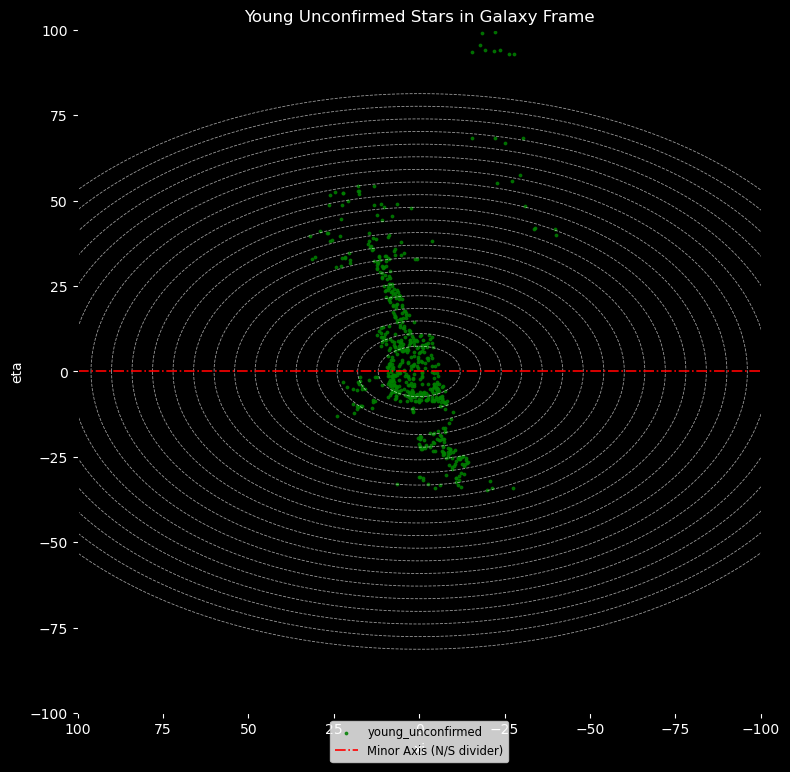

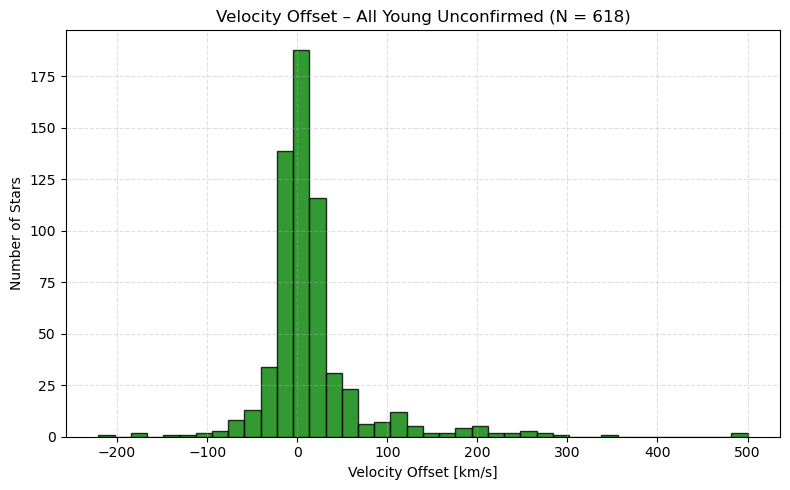

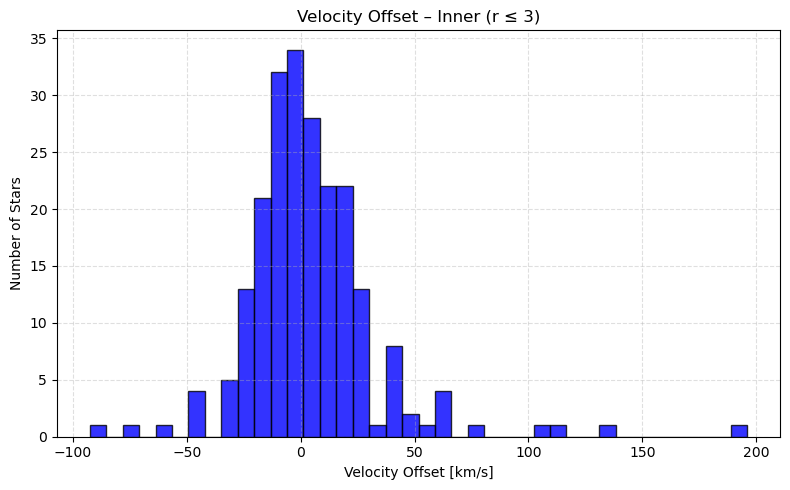

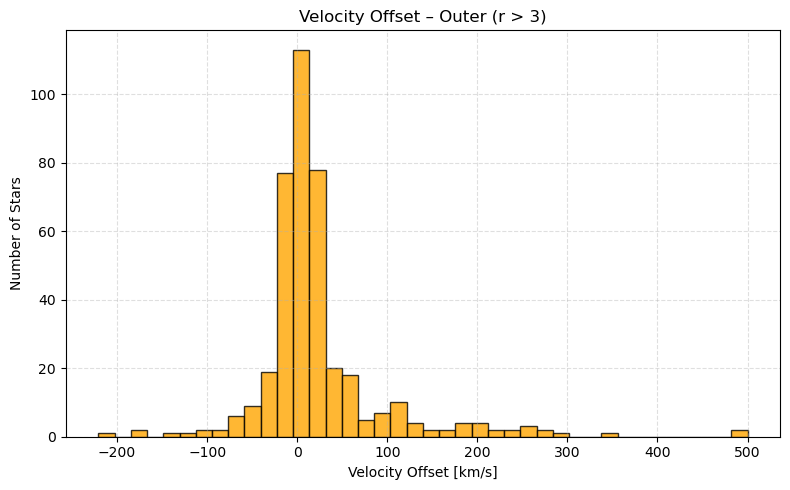

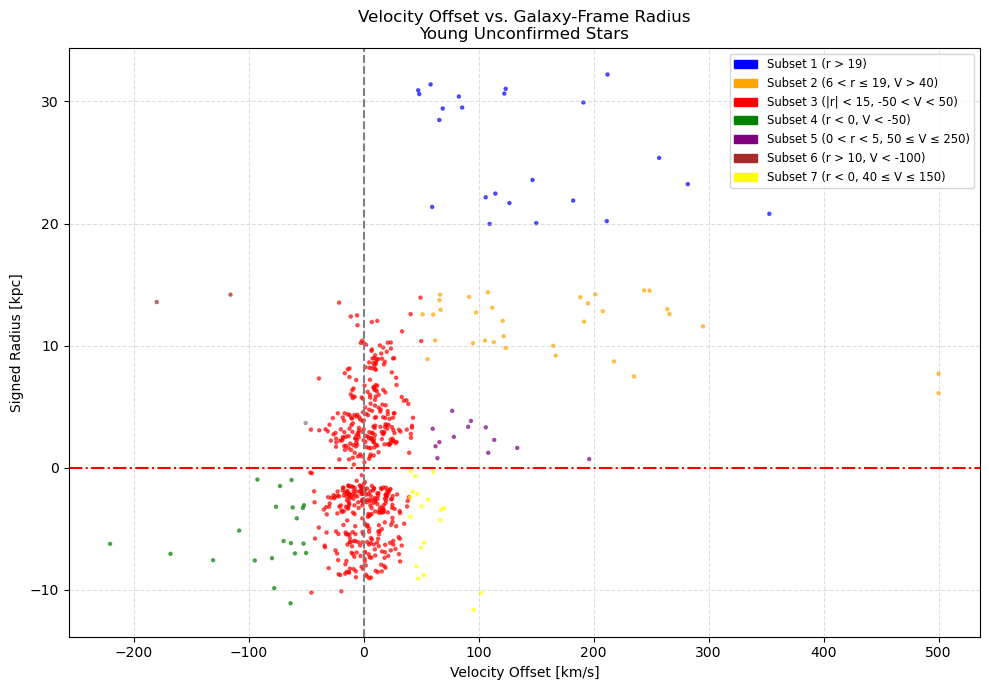

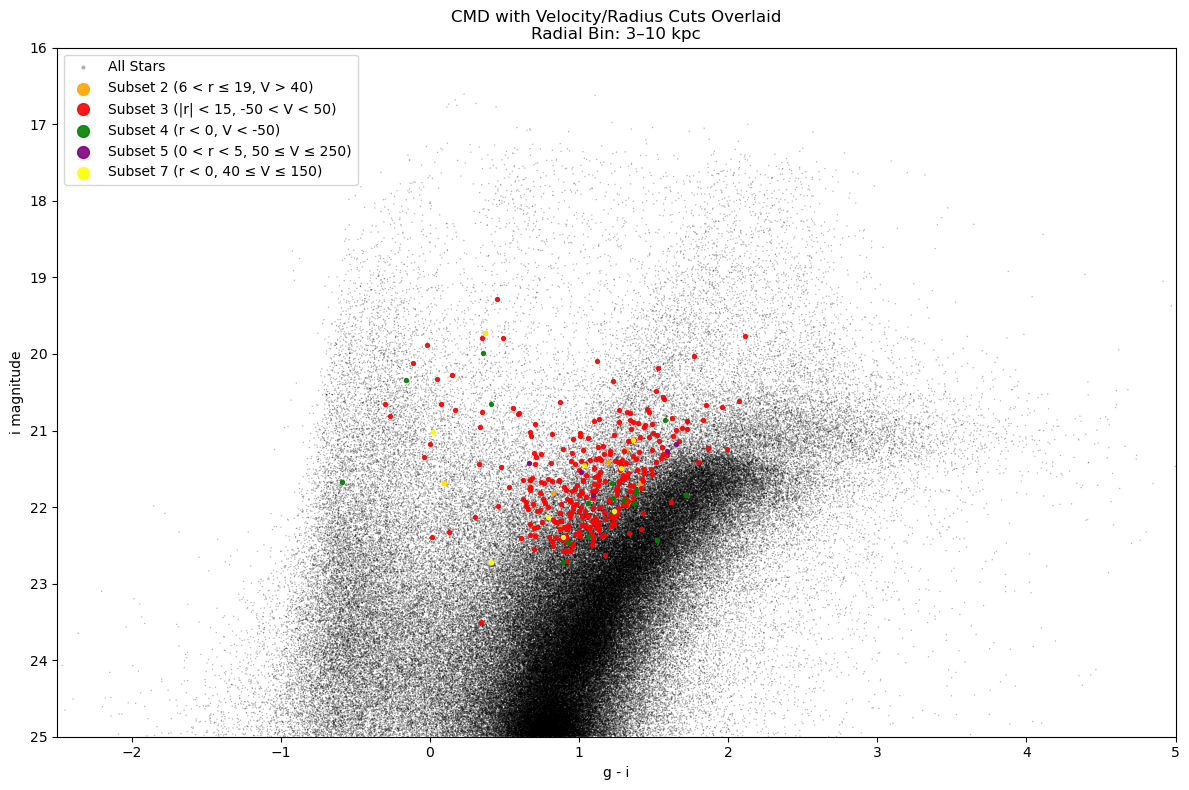

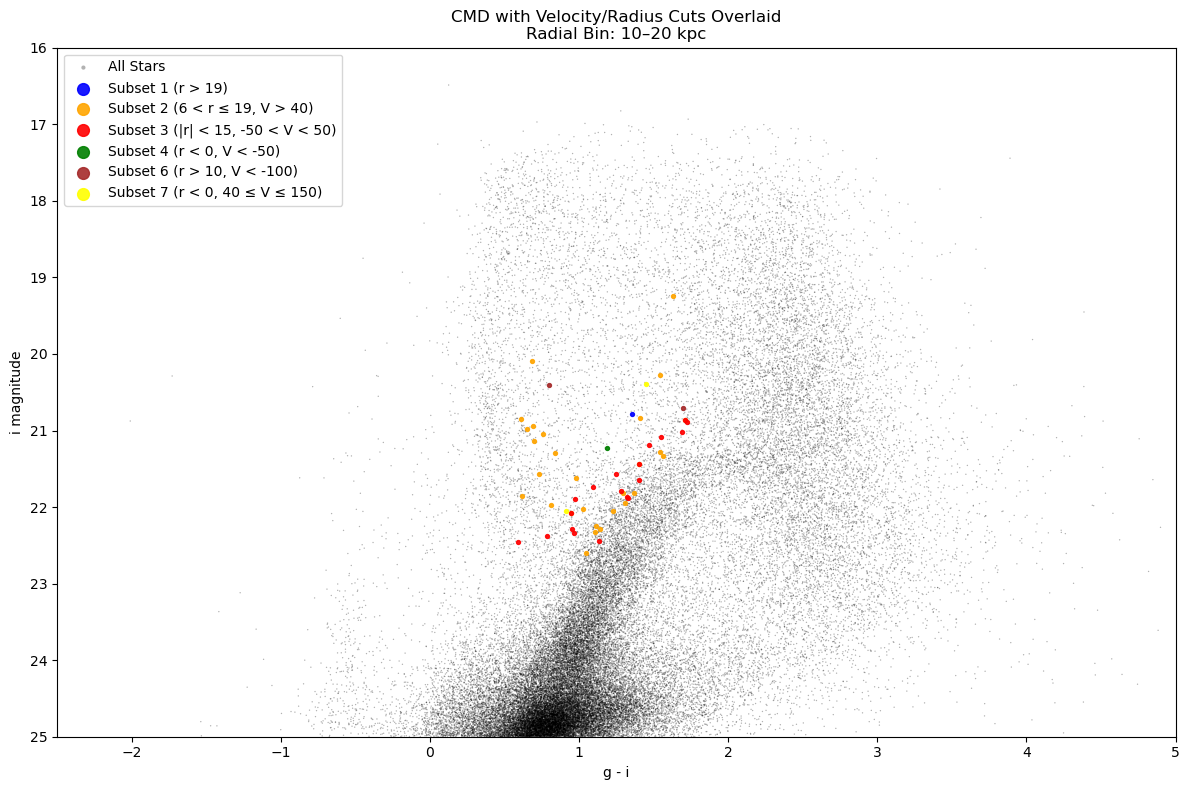

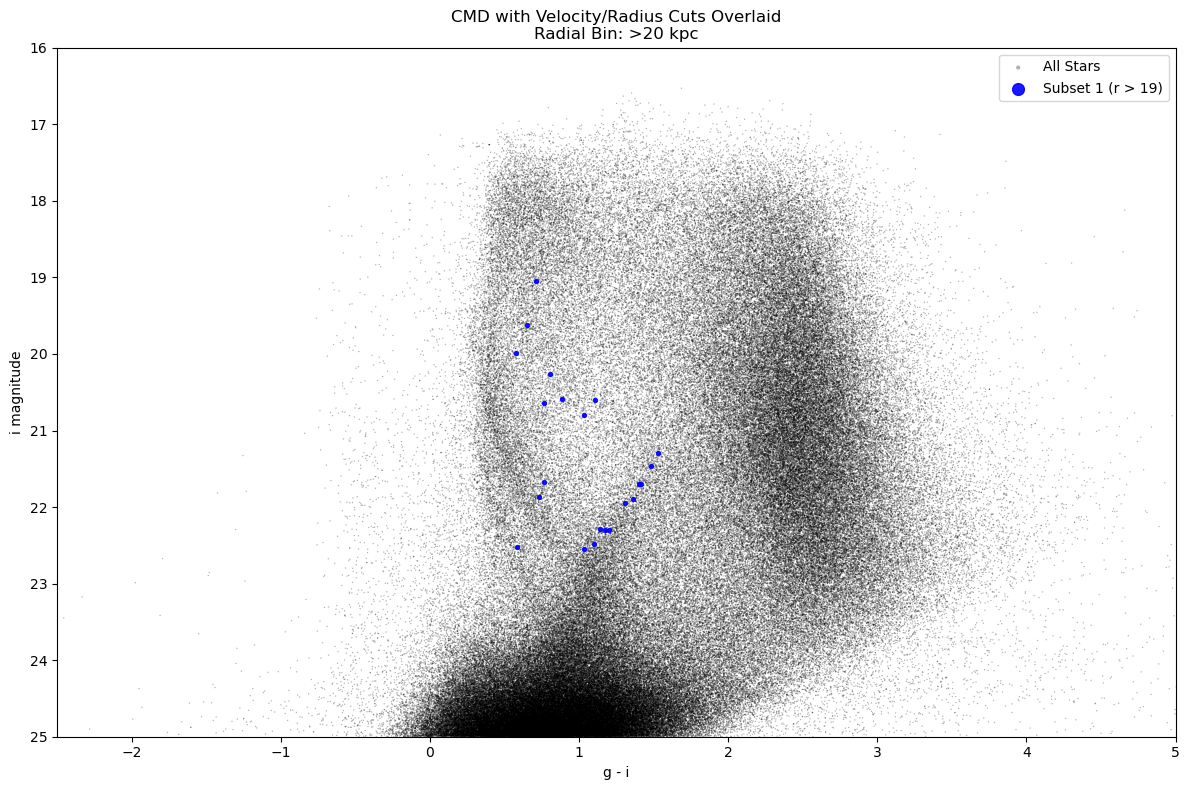

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from astropy.coordinates import SkyCoord
import astropy.units as u

# === Setup ===
delta = 3
center = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)
inc_rad = np.deg2rad(52)
r_deproj_kpc_values = np.arange(delta, 34, 1.5)

# === Load and prepare star data ===
df_young_unconfirmed = df[df['age_group'] == 'young_unconfirmed'].copy()
coords = SkyCoord(ra=df_young_unconfirmed['RA_DEG'].values * u.deg,
                  dec=df_young_unconfirmed['DEC_DEG'].values * u.deg)
df_young_unconfirmed = compute_deprojected_radius(df_young_unconfirmed)
diskmodel = load_disk_model('./Kam2017_table4.dat')
df_young_unconfirmed['V_model'] = compute_model_los_velocity(coords, diskmodel)
df_young_unconfirmed['V_offset'] = df_young_unconfirmed['VCORR_STAT'] - df_young_unconfirmed['V_model']

# === Ellipse and Minor Axis plot ===
offset = coords.transform_to(center.skyoffset_frame())
xi, eta = offset.lon.arcminute, offset.lat.arcminute
plt.figure(figsize=(8, 10), facecolor='black')
ax = plt.gca(); ax.set_facecolor('black')
plt.scatter(xi, eta, color='green', s=3, alpha=0.8, label='young_unconfirmed')
for r_kpc in r_deproj_kpc_values:
    r_arcmin = (r_kpc / 859) * (180 / np.pi) * 60
    theta = np.linspace(0, 2 * np.pi, 500)
    x, y = r_arcmin * np.cos(theta), r_arcmin * np.sin(theta) * np.cos(inc_rad)
    plt.plot(x, y, linestyle='--', color='white', linewidth=0.6, alpha=0.6)
plt.axhline(0, color='red', linestyle='-.', linewidth=1.2, label='Minor Axis (N/S divider)')
plt.xlabel("xi", color='white'); plt.ylabel("eta", color='white')
plt.tick_params(colors='white'); plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize='small')
plt.title("Young Unconfirmed Stars in Galaxy Frame", color='white')
plt.xlim(-100, 100); plt.ylim(-100, 100); ax.set_aspect('equal'); plt.gca().invert_xaxis(); plt.tight_layout(); plt.show()

# === Velocity Offset Histograms ===
def plot_hist(data, label, color):
    plt.figure(figsize=(8, 5))
    plt.hist(data.clip(-300, 500), bins=40, color=color, alpha=0.8, edgecolor='black')
    plt.xlabel('Velocity Offset [km/s]'); plt.ylabel('Number of Stars'); plt.grid(True, linestyle='--', alpha=0.4)
    plt.title(label); plt.tight_layout(); plt.show()

plot_hist(df_young_unconfirmed['V_offset'], f'Velocity Offset – All Young Unconfirmed (N = {len(df_young_unconfirmed)})', 'green')
plot_hist(df_young_unconfirmed[df_young_unconfirmed['r_deproj_kpc'] <= delta]['V_offset'], f'Velocity Offset – Inner (r ≤ {delta})', 'blue')
plot_hist(df_young_unconfirmed[df_young_unconfirmed['r_deproj_kpc'] > delta]['V_offset'], f'Velocity Offset – Outer (r > {delta})', 'orange')

# === Subset definitions ===
sign = np.sign(eta)
df = df_young_unconfirmed.copy()
df['signed_radius'] = df['r_deproj_kpc'] * sign
df['V_offset_clipped'] = df['V_offset'].clip(-300, 500)

subset_1 = df[df['signed_radius'] > 19]
subset_2 = df[(df['signed_radius'] > 6) & (df['signed_radius'] <= 19) & (df['V_offset'] > 40)]
subset_3 = df[(df['signed_radius'].abs() < 15) & (df['V_offset'].between(-50, 50))]
subset_4 = df[(df['signed_radius'] < 0) & (df['V_offset'] < -50)]
subset_5 = df[(df['signed_radius'].between(0, 5)) & (df['V_offset'].between(50, 250))]
subset_6 = df[(df['signed_radius'] > 10) & (df['V_offset'] < -100)]
subset_7 = df[(df['signed_radius'] < 0) & (df['V_offset'].between(40, 150))]

# === Subset color assignments ===
subset_colors = {
    'Subset 1 (r > 19)': 'blue',
    'Subset 2 (6 < r ≤ 19, V > 40)': 'orange',
    'Subset 3 (|r| < 15, -50 < V < 50)': 'red',
    'Subset 4 (r < 0, V < -50)': 'green',
    'Subset 5 (0 < r < 5, 50 ≤ V ≤ 250)': 'purple',
    'Subset 6 (r > 10, V < -100)': 'brown',
    'Subset 7 (r < 0, 40 ≤ V ≤ 150)': 'yellow'
}
subset_labels = list(subset_colors.keys())
raw_subsets = [subset_1, subset_2, subset_3, subset_4, subset_5, subset_6, subset_7]

# === Plot velocity vs signed radius with subset colors ===
df['color'] = 'gray'
for color, subset in zip(subset_colors.values(), raw_subsets):
    df.loc[subset.index, 'color'] = color

plt.figure(figsize=(10, 7))
plt.scatter(df['V_offset_clipped'], df['signed_radius'], s=5, c=df['color'], alpha=0.6)
plt.axvline(0, color='gray', linestyle='--'); plt.axhline(0, color='red', linestyle='-.')
legend_elements = [mpatches.Patch(color=c, label=l) for l, c in subset_colors.items()]
plt.legend(handles=legend_elements, loc='best', fontsize='small')
plt.xlabel('Velocity Offset [km/s]'); plt.ylabel('Signed Radius [kpc]')
plt.title('Velocity Offset vs. Galaxy-Frame Radius\nYoung Unconfirmed Stars')
plt.grid(True, linestyle='--', alpha=0.4); plt.tight_layout(); plt.show()

# === CMD plots per radial bin ===
panda['color'] = panda['g'] - panda['i']
panda['mag'] = panda['i']
radial_bins = {
    '3–10 kpc': (panda['r_deproj_kpc'] >= 3) & (panda['r_deproj_kpc'] < 10),
    '10–20 kpc': (panda['r_deproj_kpc'] >= 10) & (panda['r_deproj_kpc'] < 20),
    '>20 kpc': (panda['r_deproj_kpc'] >= 20)
}

# Prepare subset list with color/mag
subset_list = []
for raw_subset in raw_subsets:
    s = raw_subset.copy()
    s['color'] = s['g'] - s['i']
    s['mag'] = s['i']
    subset_list.append(s)

# CMD plots
for bin_label, bin_mask in radial_bins.items():
    bin_stars = panda[bin_mask].copy()
    bin_stars['color'] = bin_stars['g'] - bin_stars['i']
    bin_stars['mag'] = bin_stars['i']

    plt.figure(figsize=(12, 8))
    plt.scatter(bin_stars['color'], bin_stars['mag'], s=1, alpha=0.3, c='k', edgecolors='none', label='All Stars')

    for subset, label in zip(subset_list, subset_labels):
        subset_in_bin = subset[
            (subset['r_deproj_kpc'] >= bin_stars['r_deproj_kpc'].min()) &
            (subset['r_deproj_kpc'] <= bin_stars['r_deproj_kpc'].max())
        ]
        if not subset_in_bin.empty:
            plt.scatter(subset_in_bin['color'], subset_in_bin['mag'],
                        s=8, alpha=0.9, color=subset_colors[label], label=label)

    plt.gca().invert_yaxis()
    plt.xlabel('g - i')
    plt.ylabel('i magnitude')
    plt.xlim(-2.5, 5)
    plt.ylim(25, 16)
    plt.title(f'CMD with Velocity/Radius Cuts Overlaid\nRadial Bin: {bin_label}')
    plt.legend(markerscale=3)
    plt.tight_layout()
    plt.show()

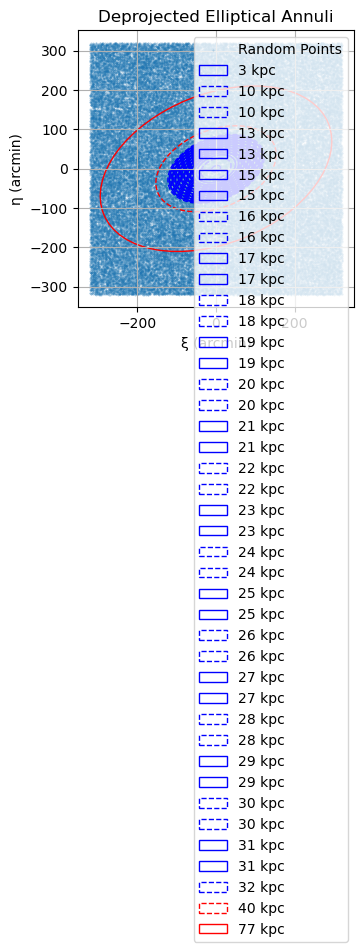


=== Area Comparison for All Bins ===
Bin (kpc)           Analytic Area          Monte Carlo Area     % Diff
---------------------------------------------------------------------------
3-10                       176.01                    176.90       0.50
10-13                      133.46                    132.61      -0.64
13-15                      108.31                    106.75      -1.44
15-16                       59.96                     55.04      -8.20
16-17                       63.83                     66.30       3.88
17-18                       67.70                     67.84       0.21
18-19                       71.56                     69.12      -3.41
19-20                       75.43                     73.22      -2.94
20-21                       79.30                     78.08      -1.54
21-22                       83.17                     80.64      -3.04
22-23                       87.04                     93.44       7.36
23-24                       90.91 

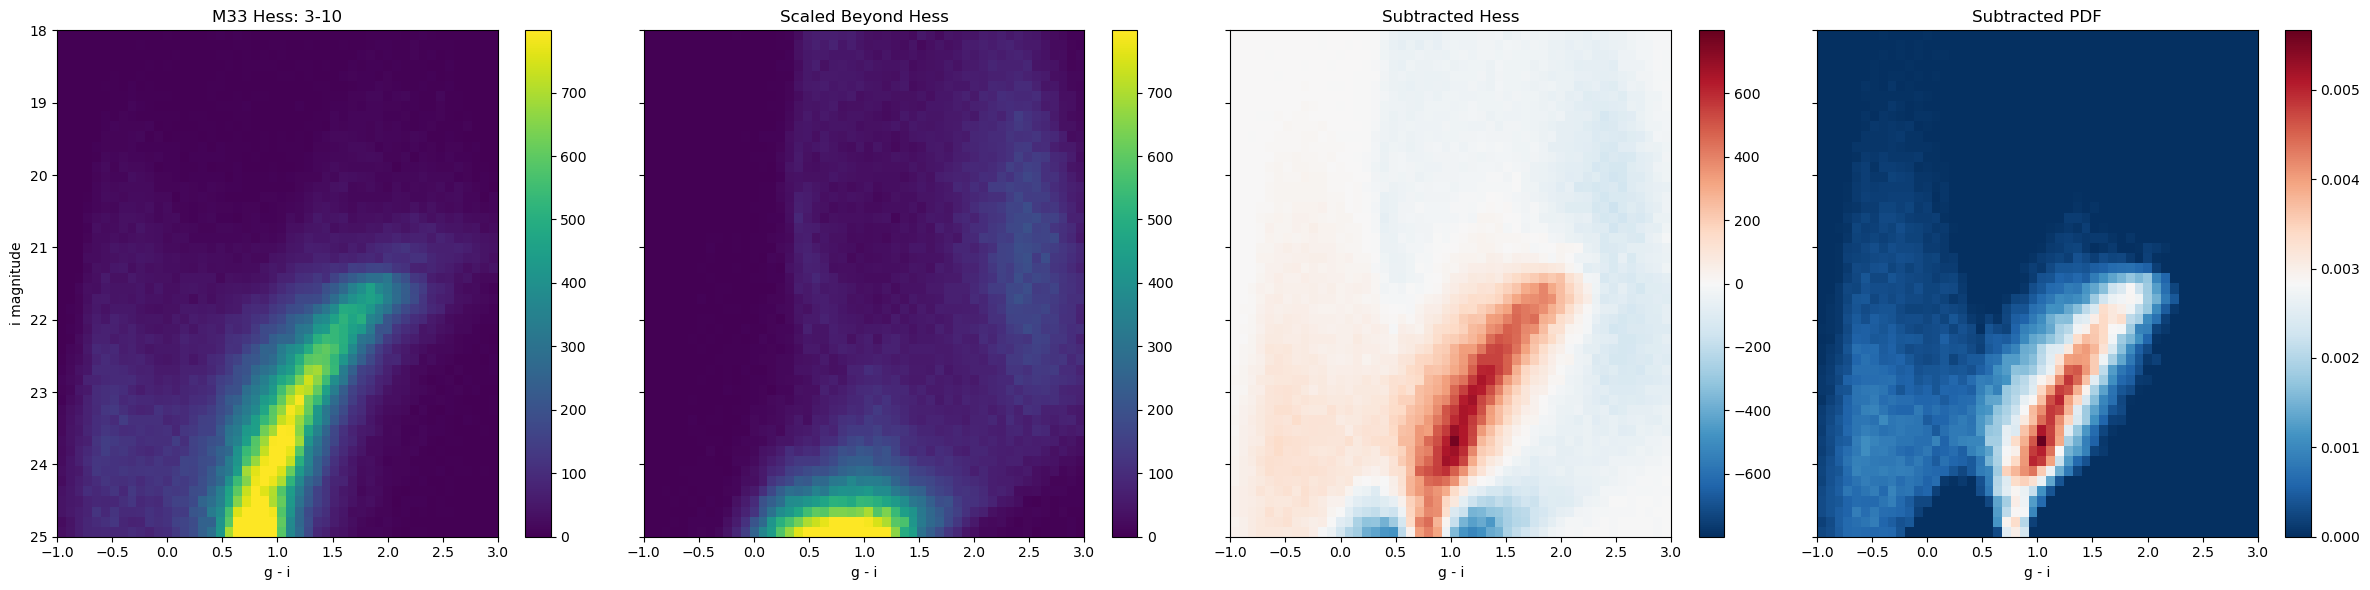

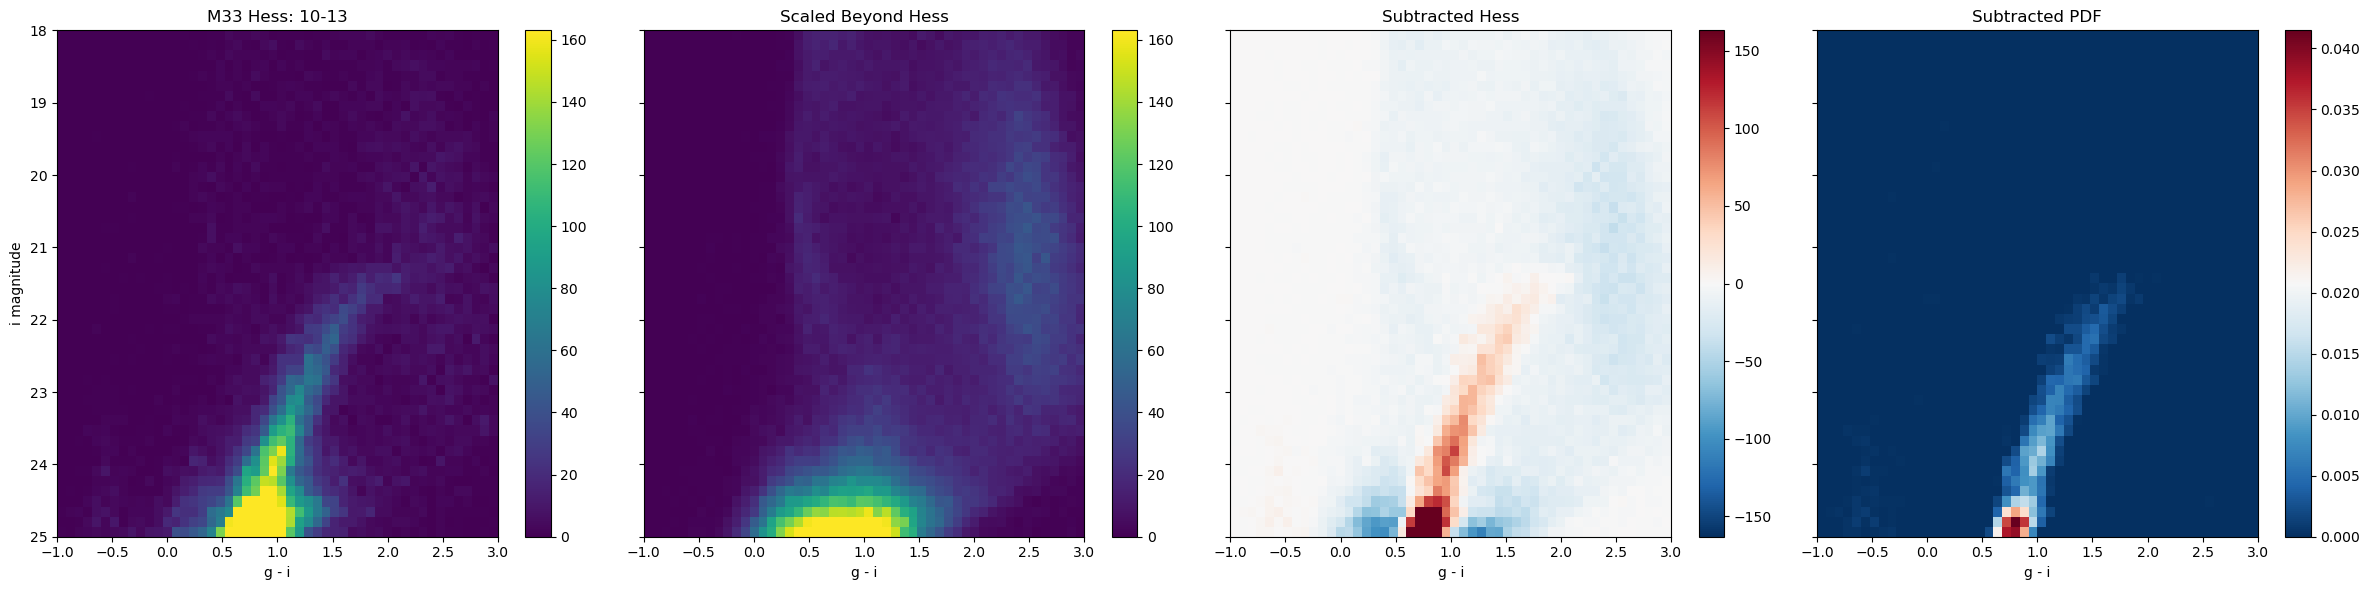

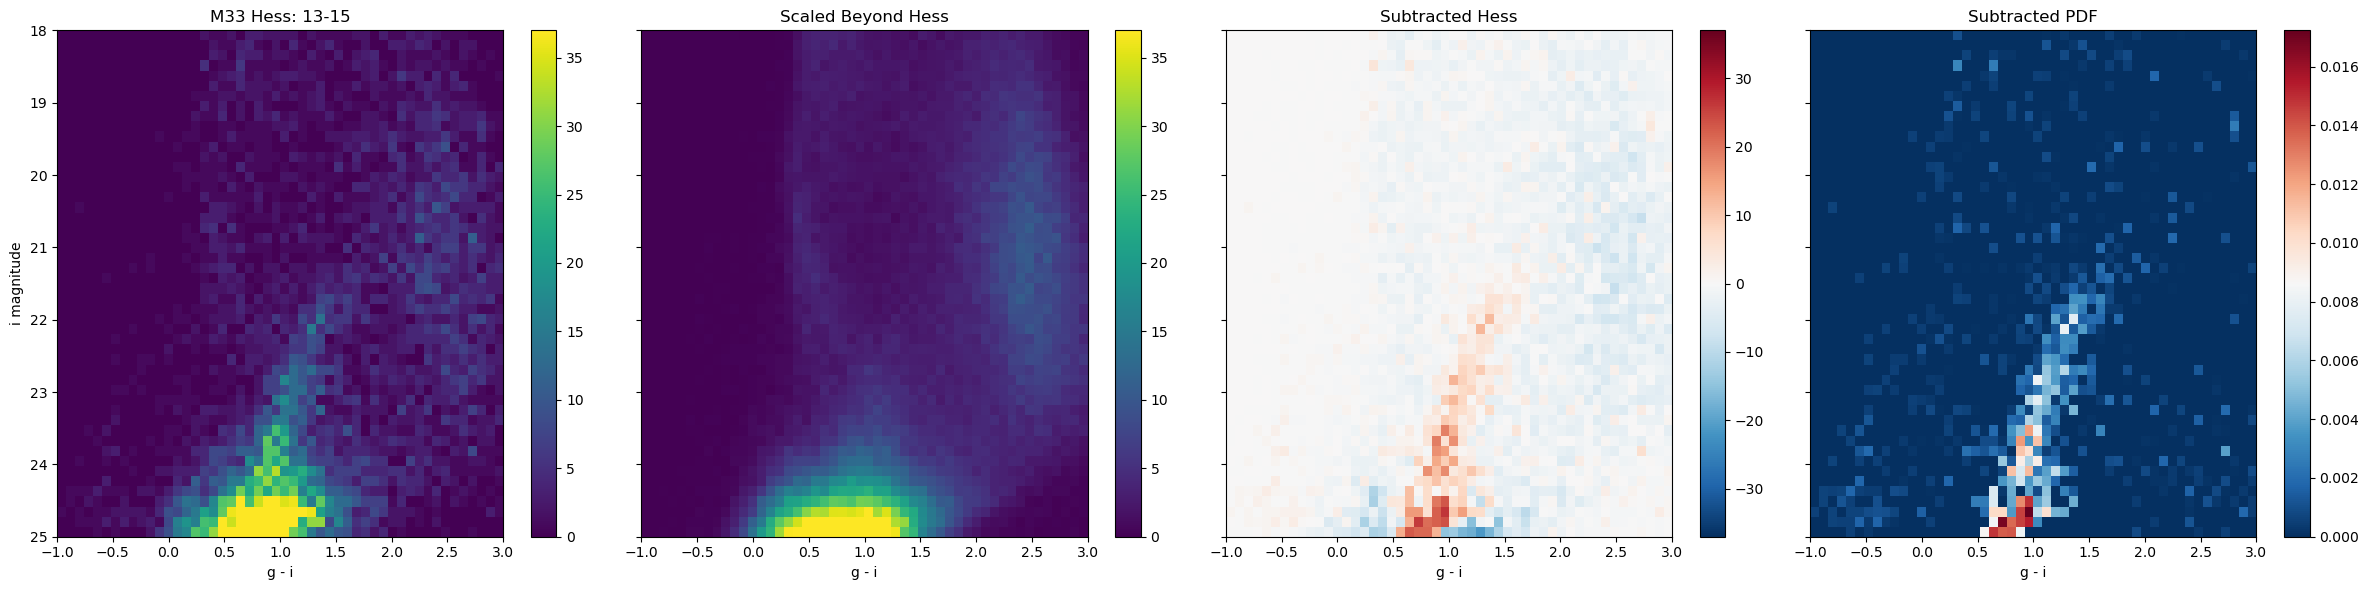

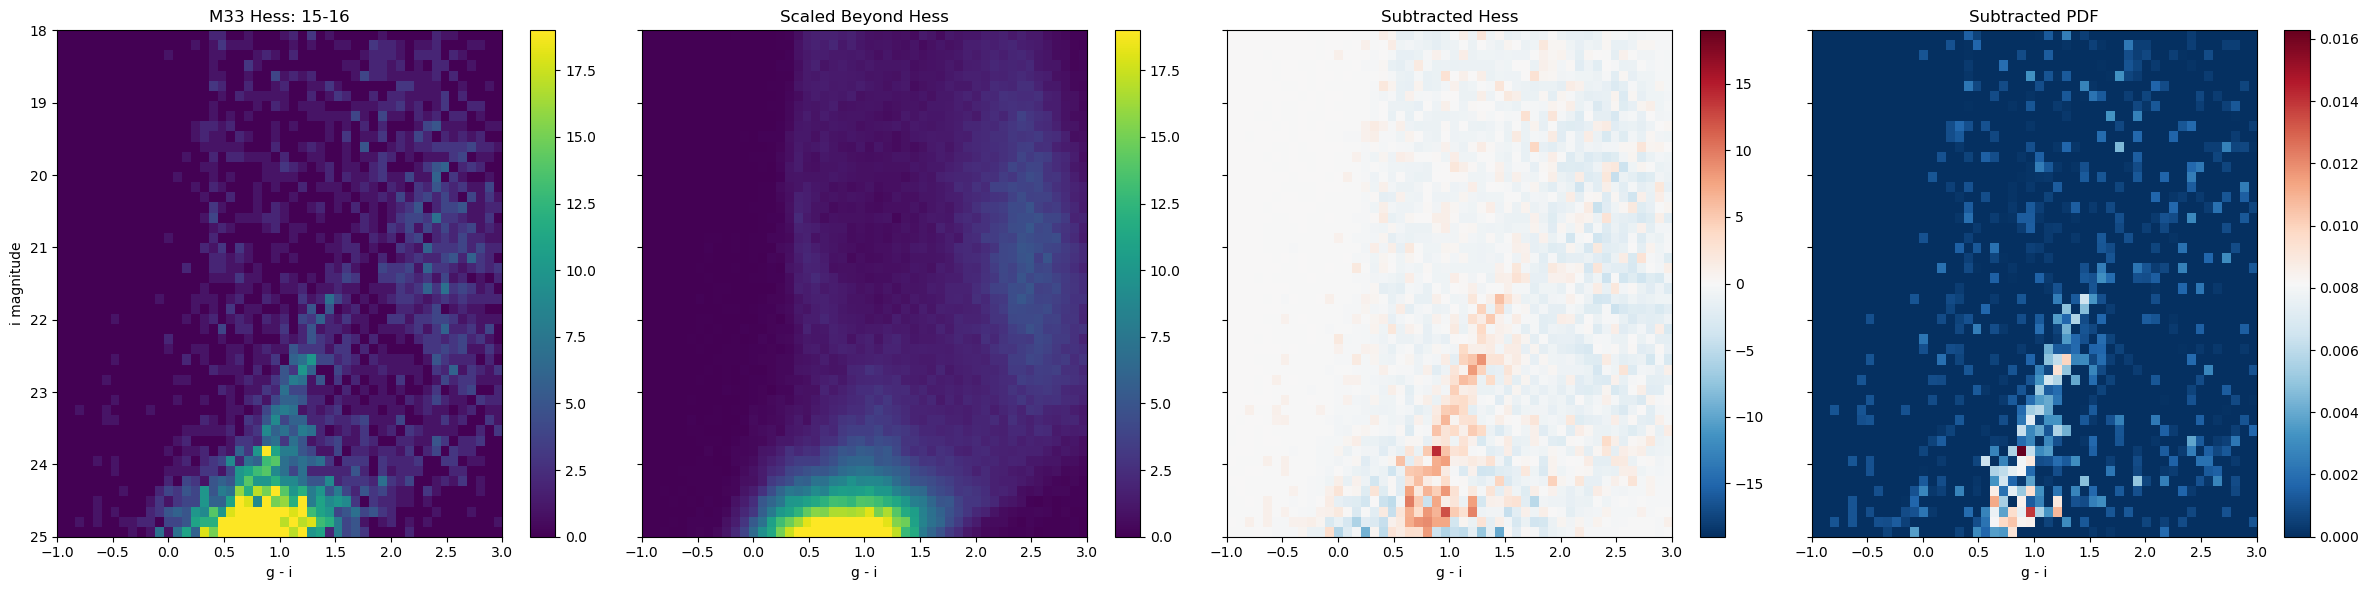

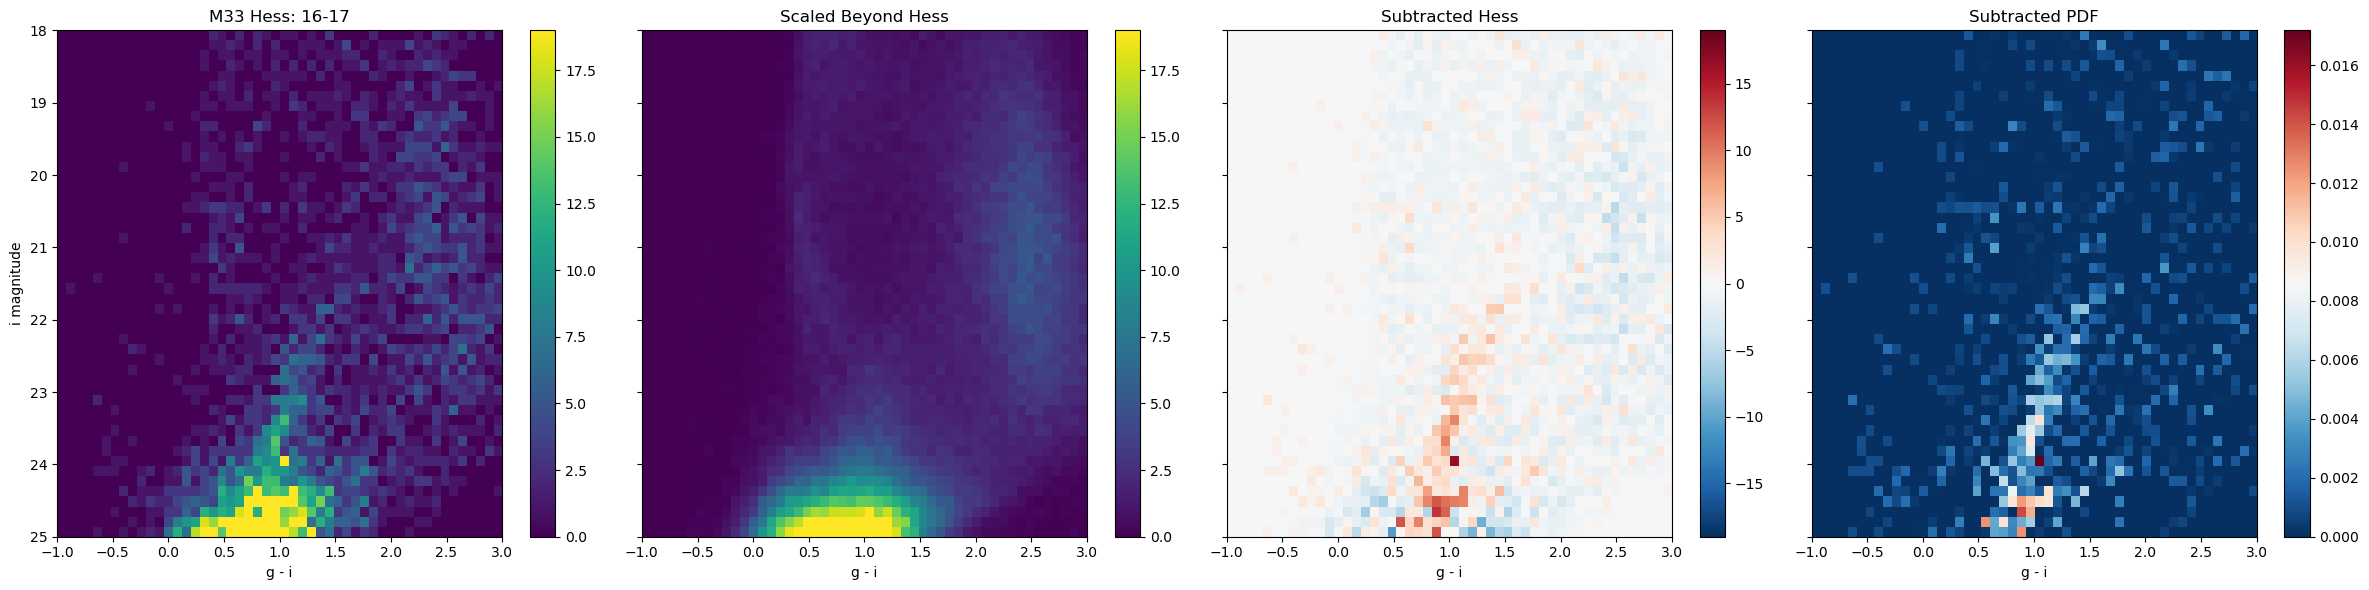

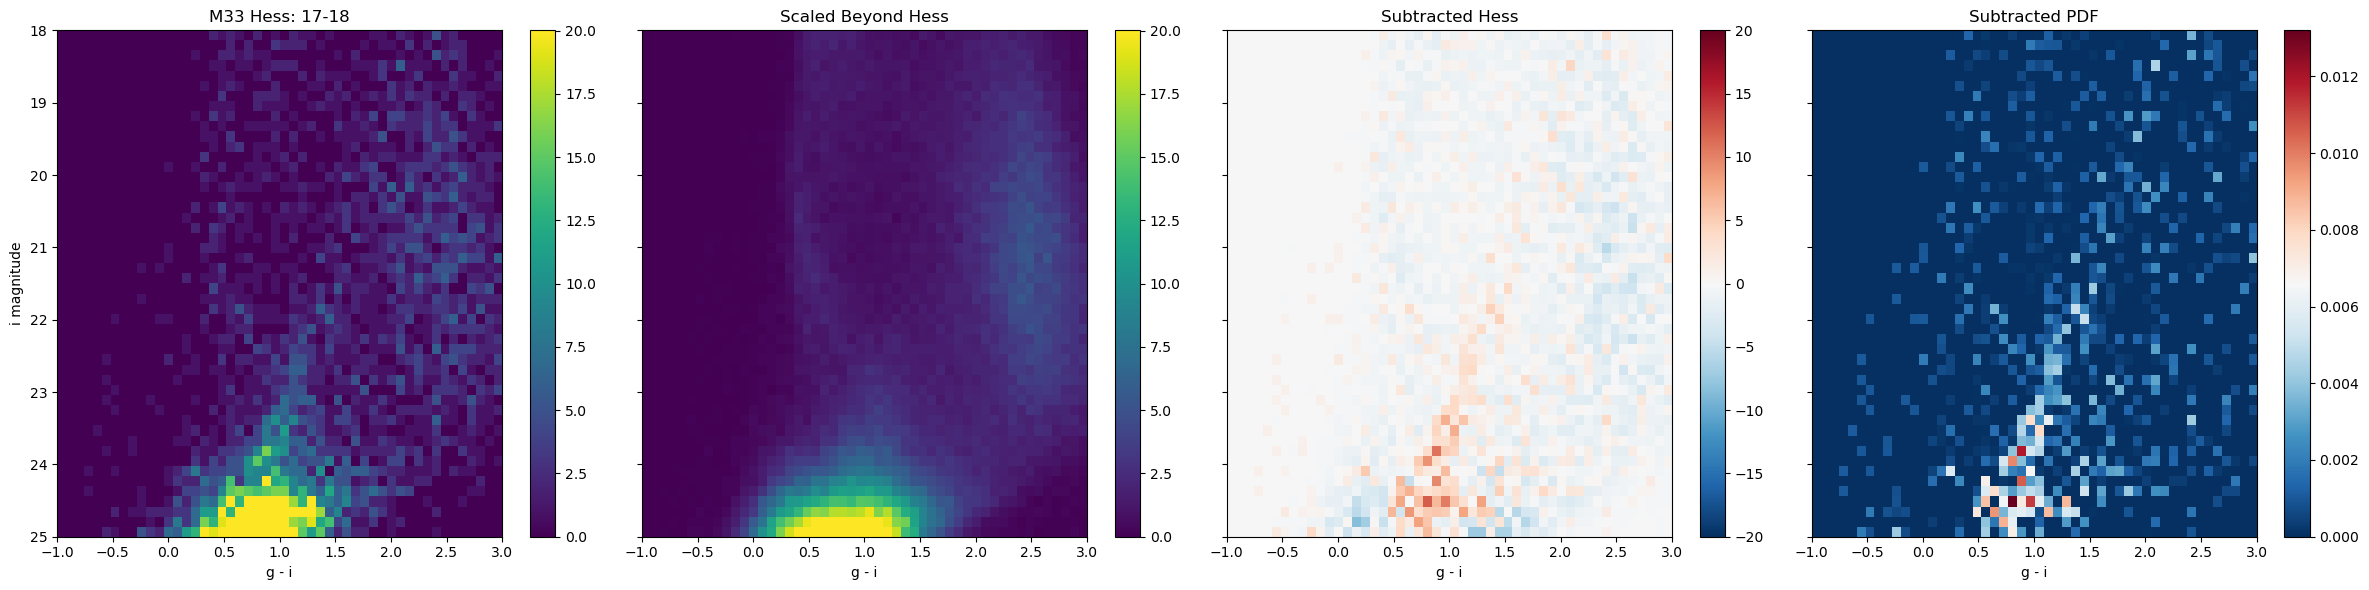

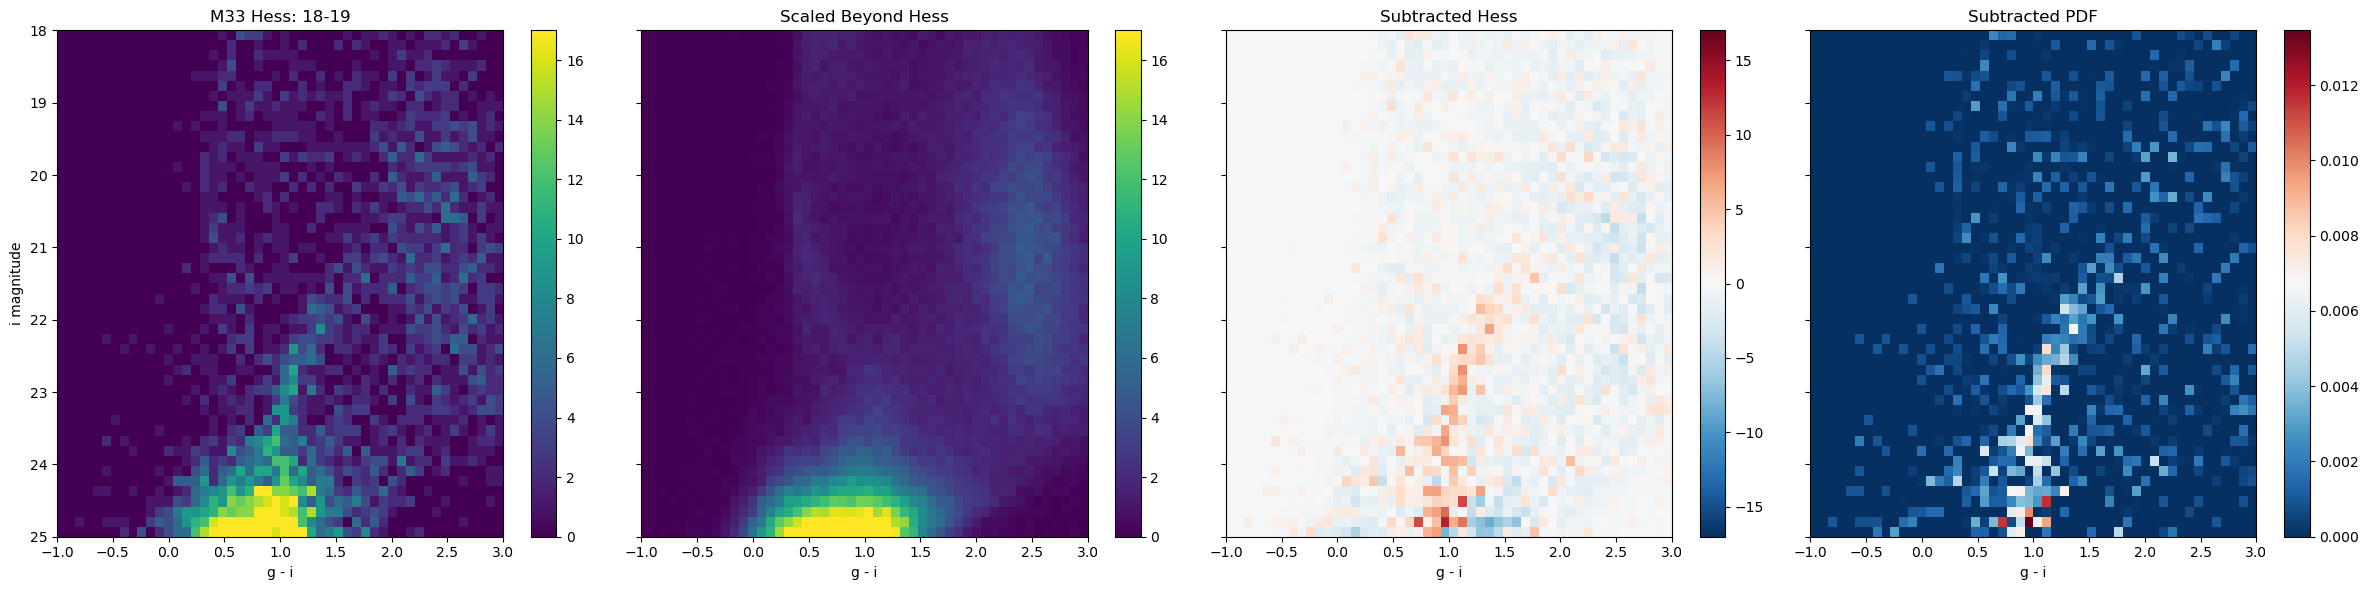

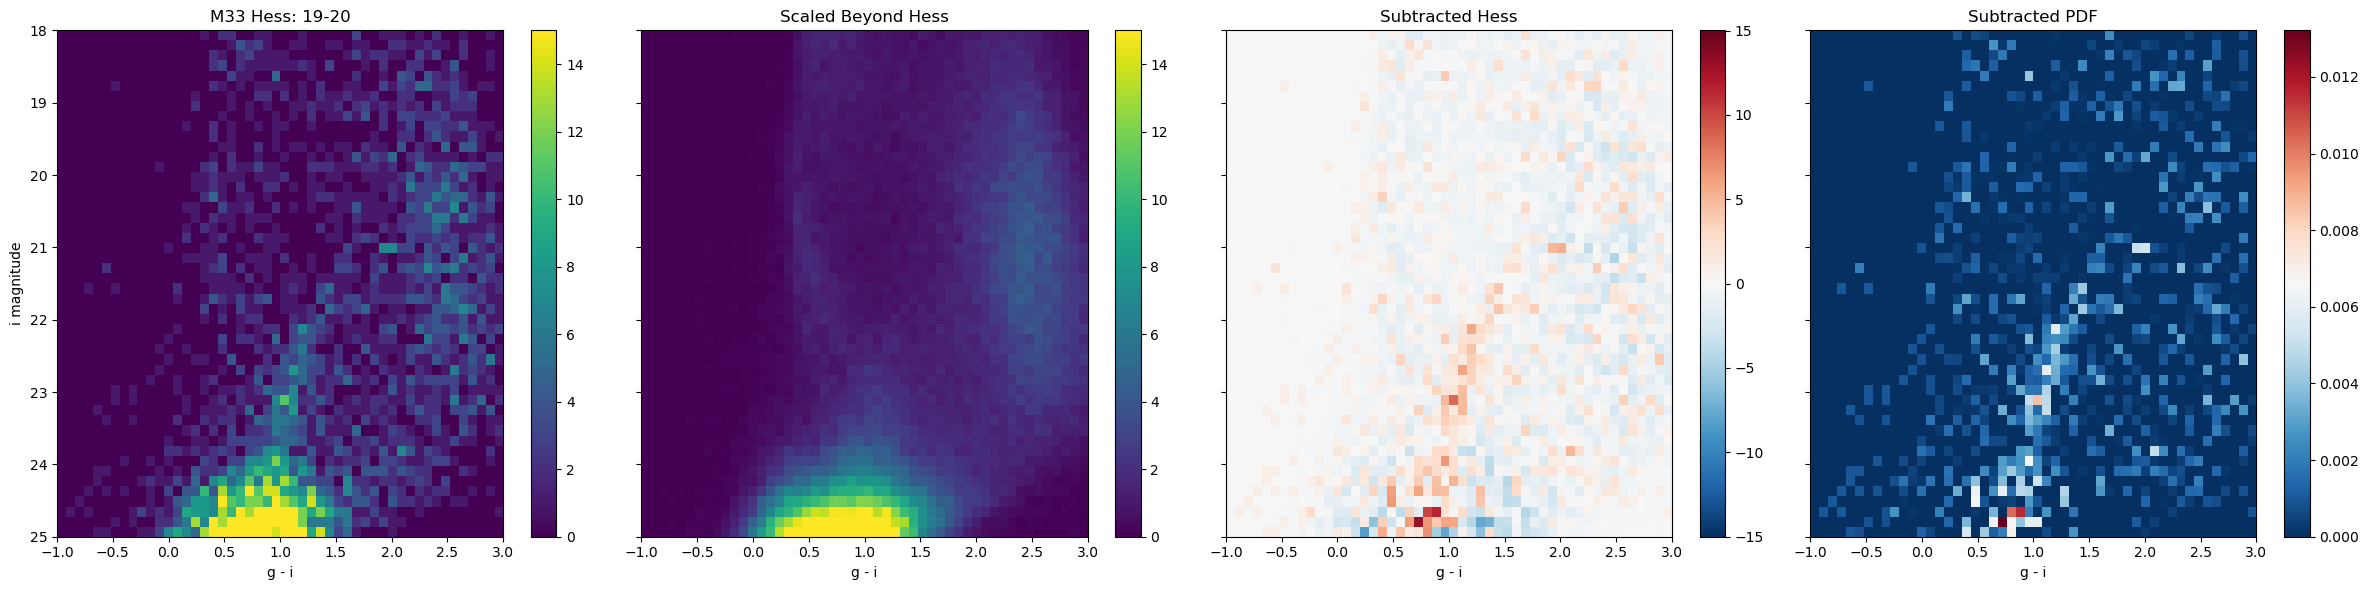

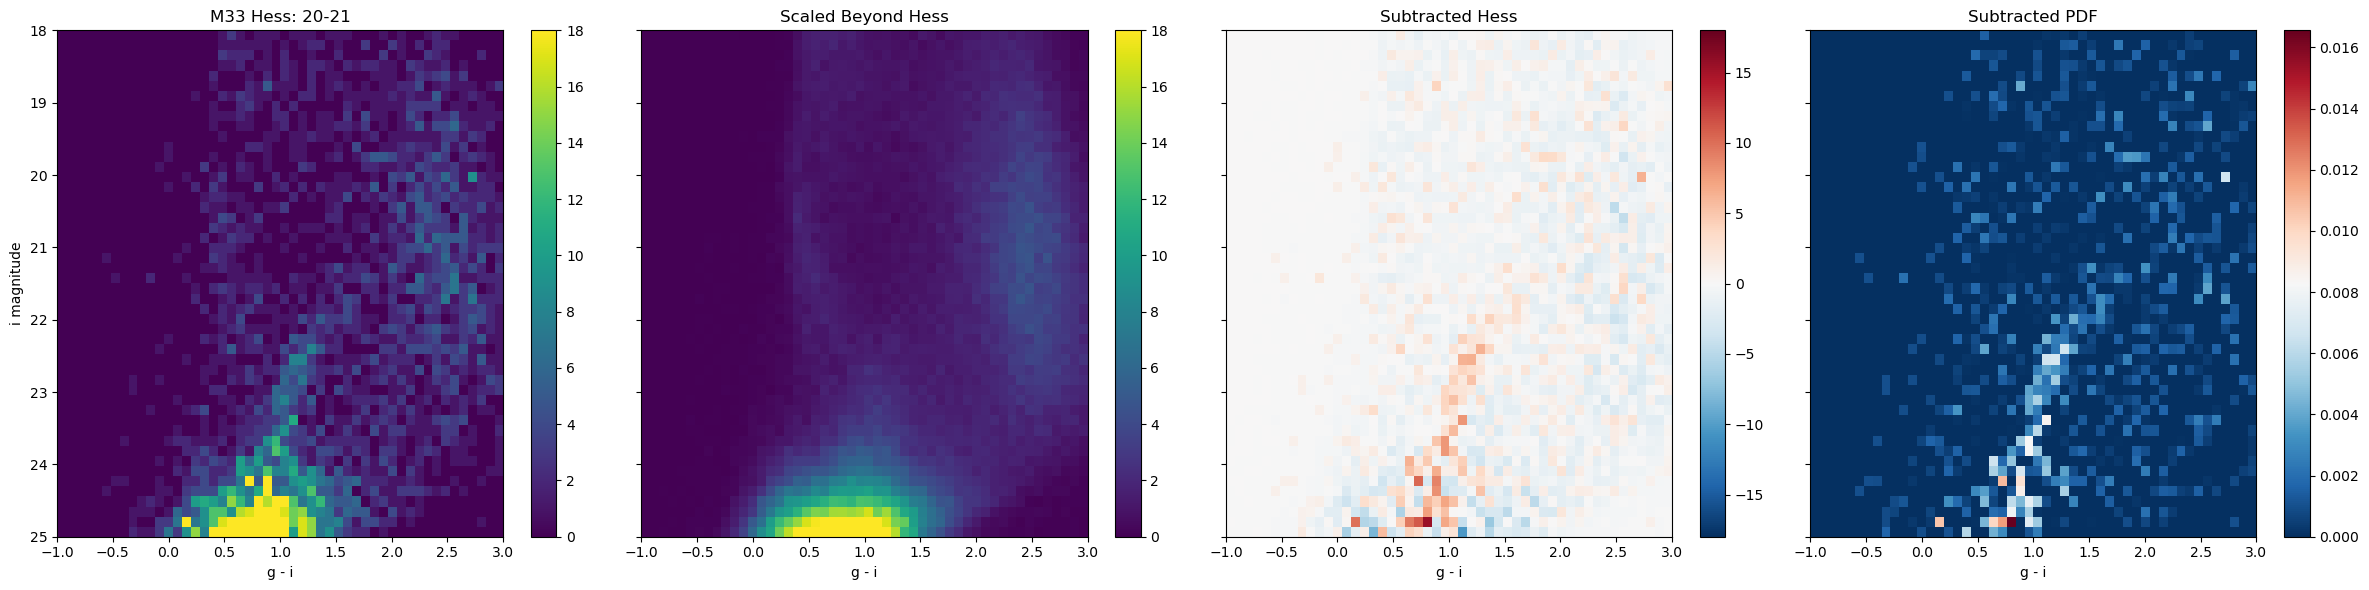

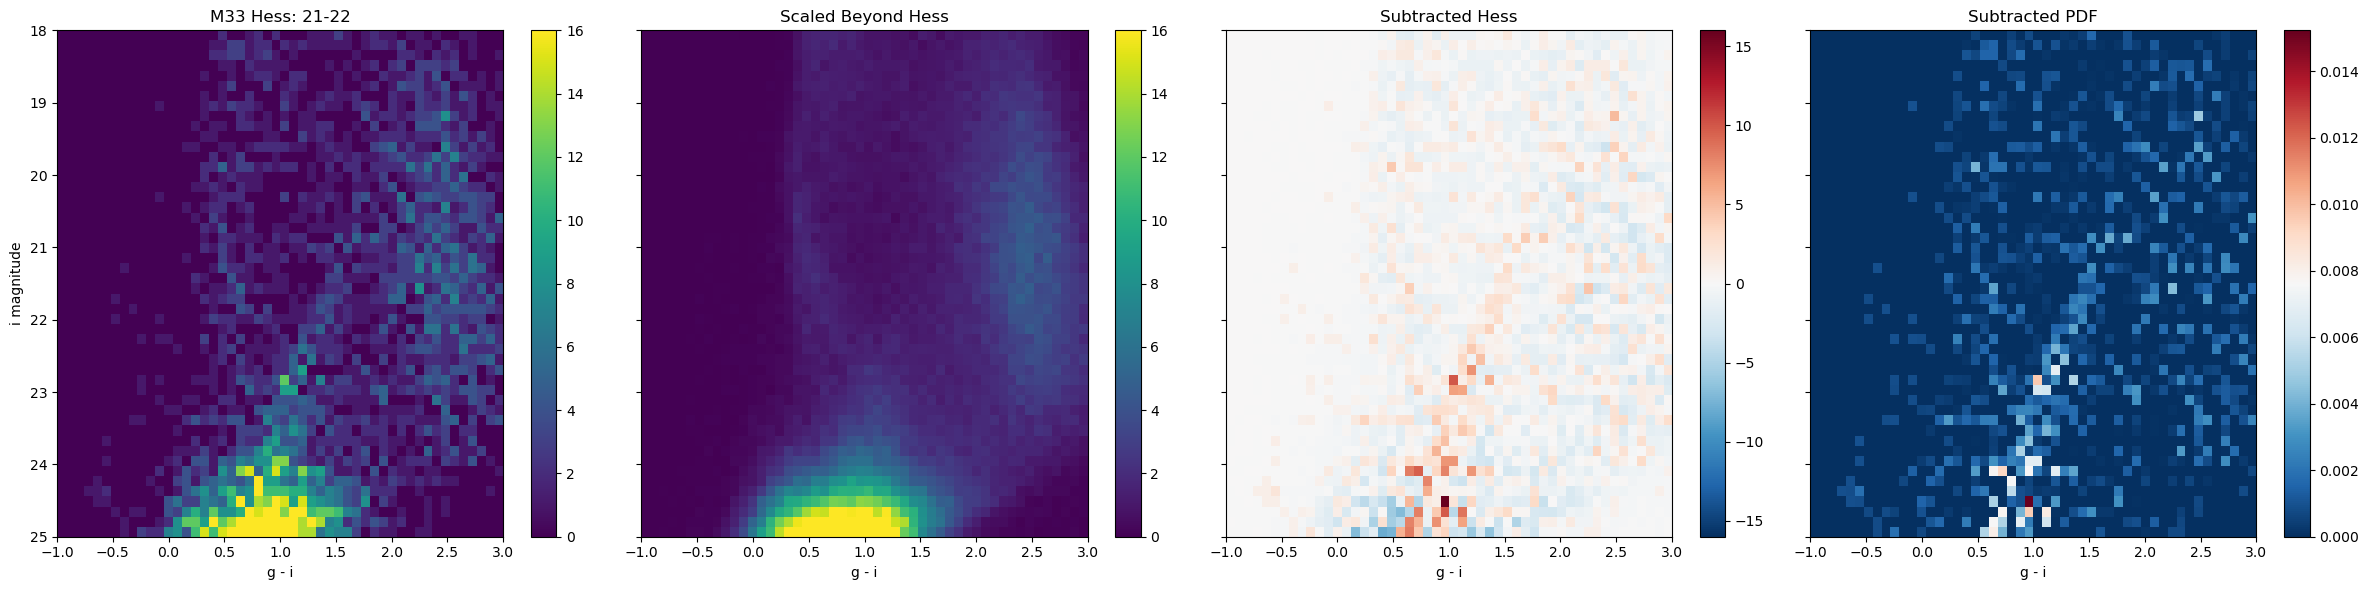

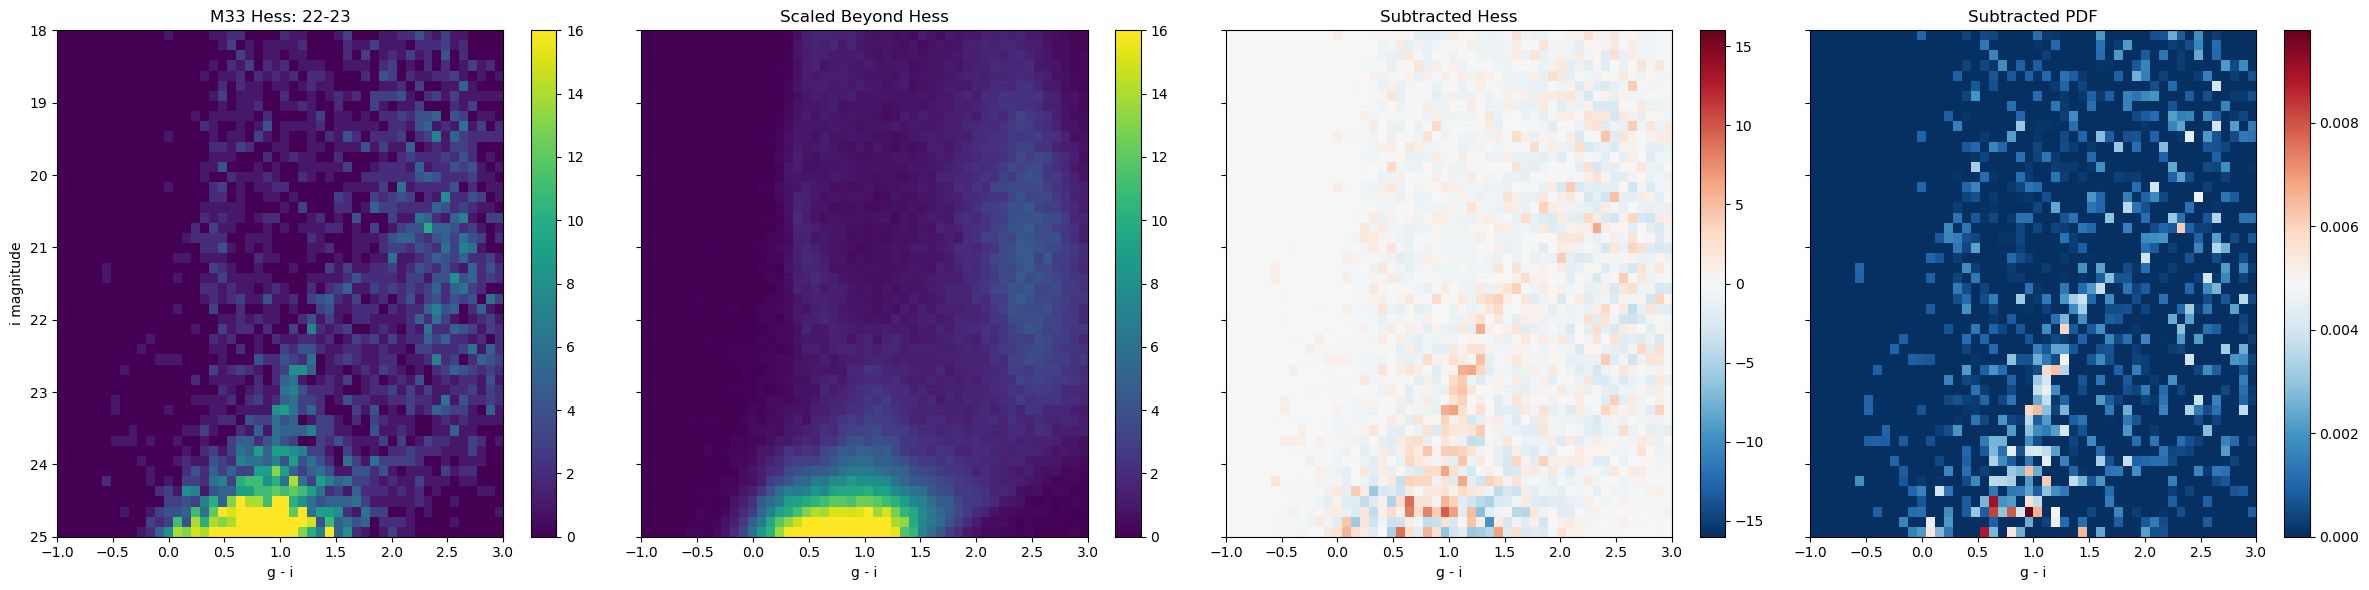

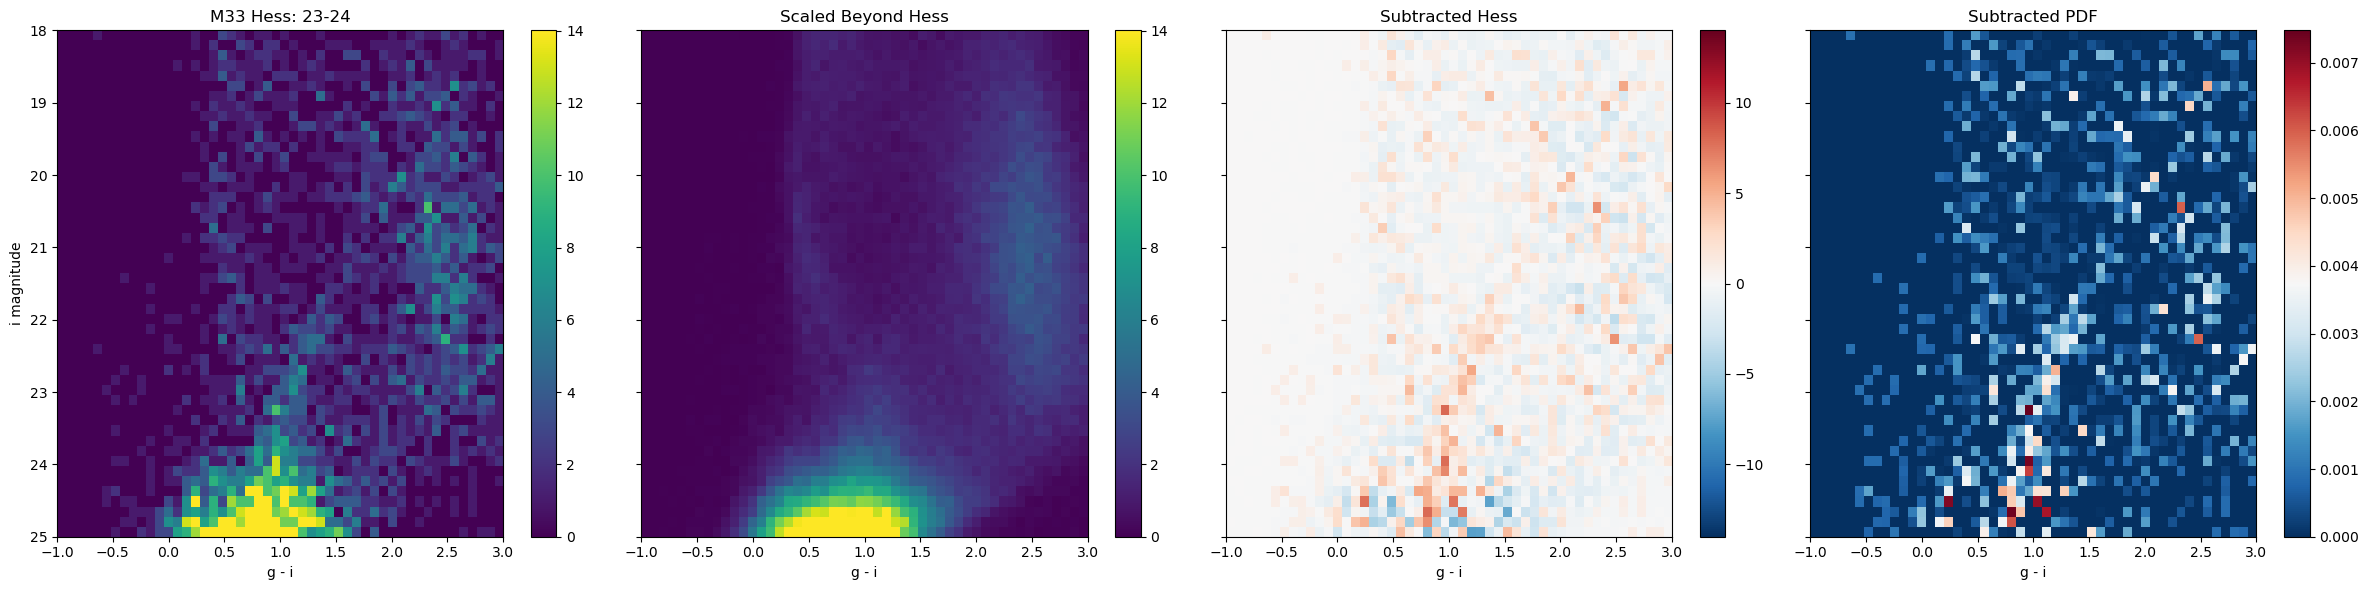

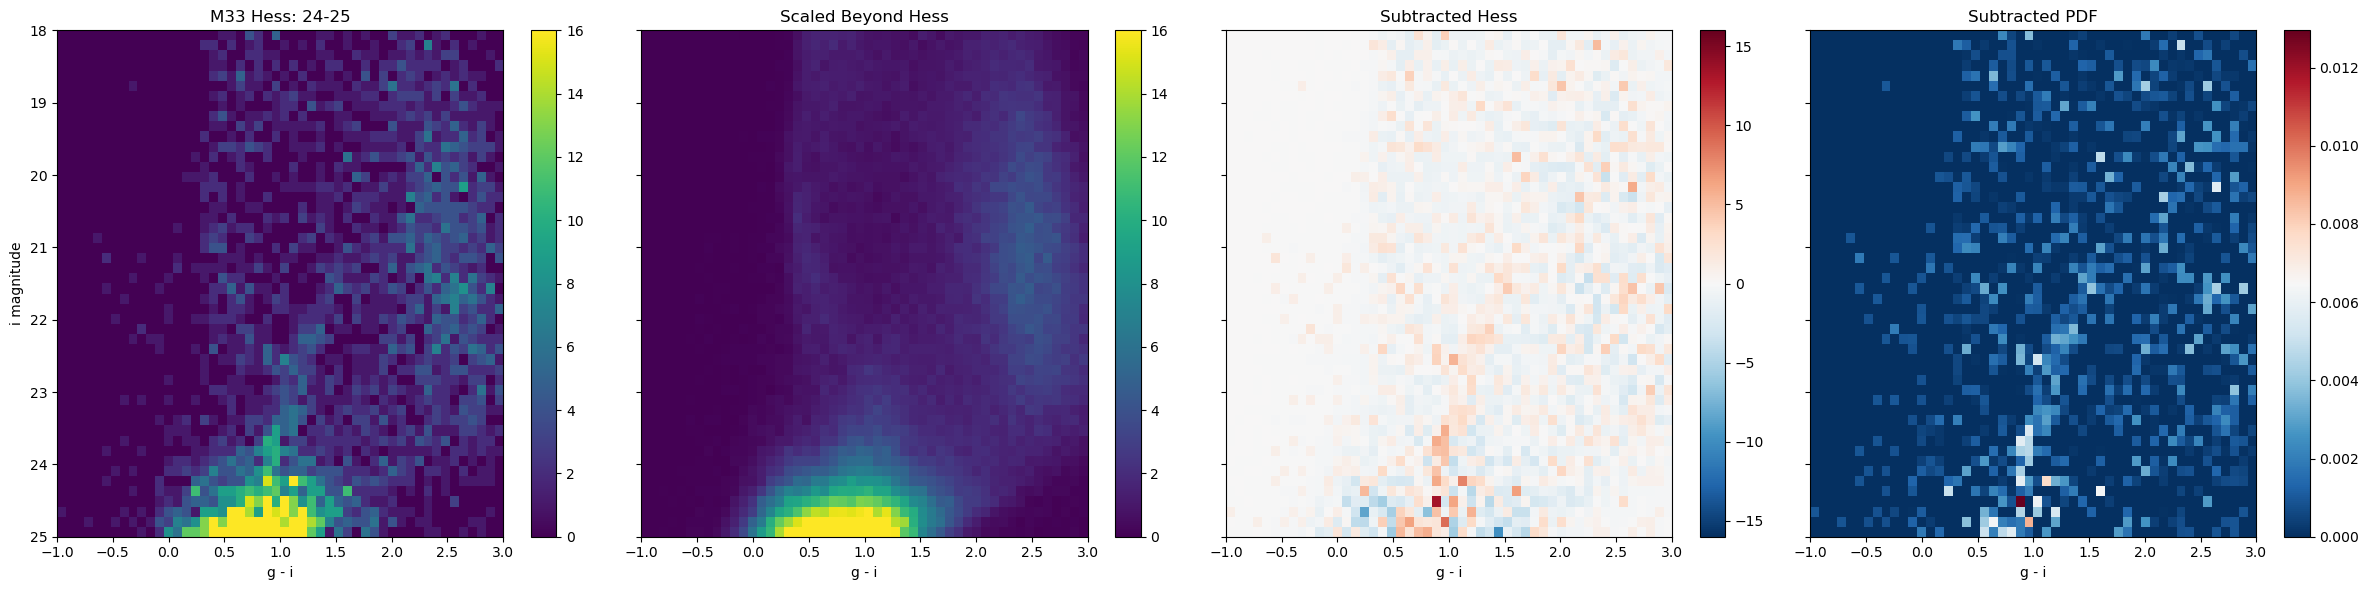

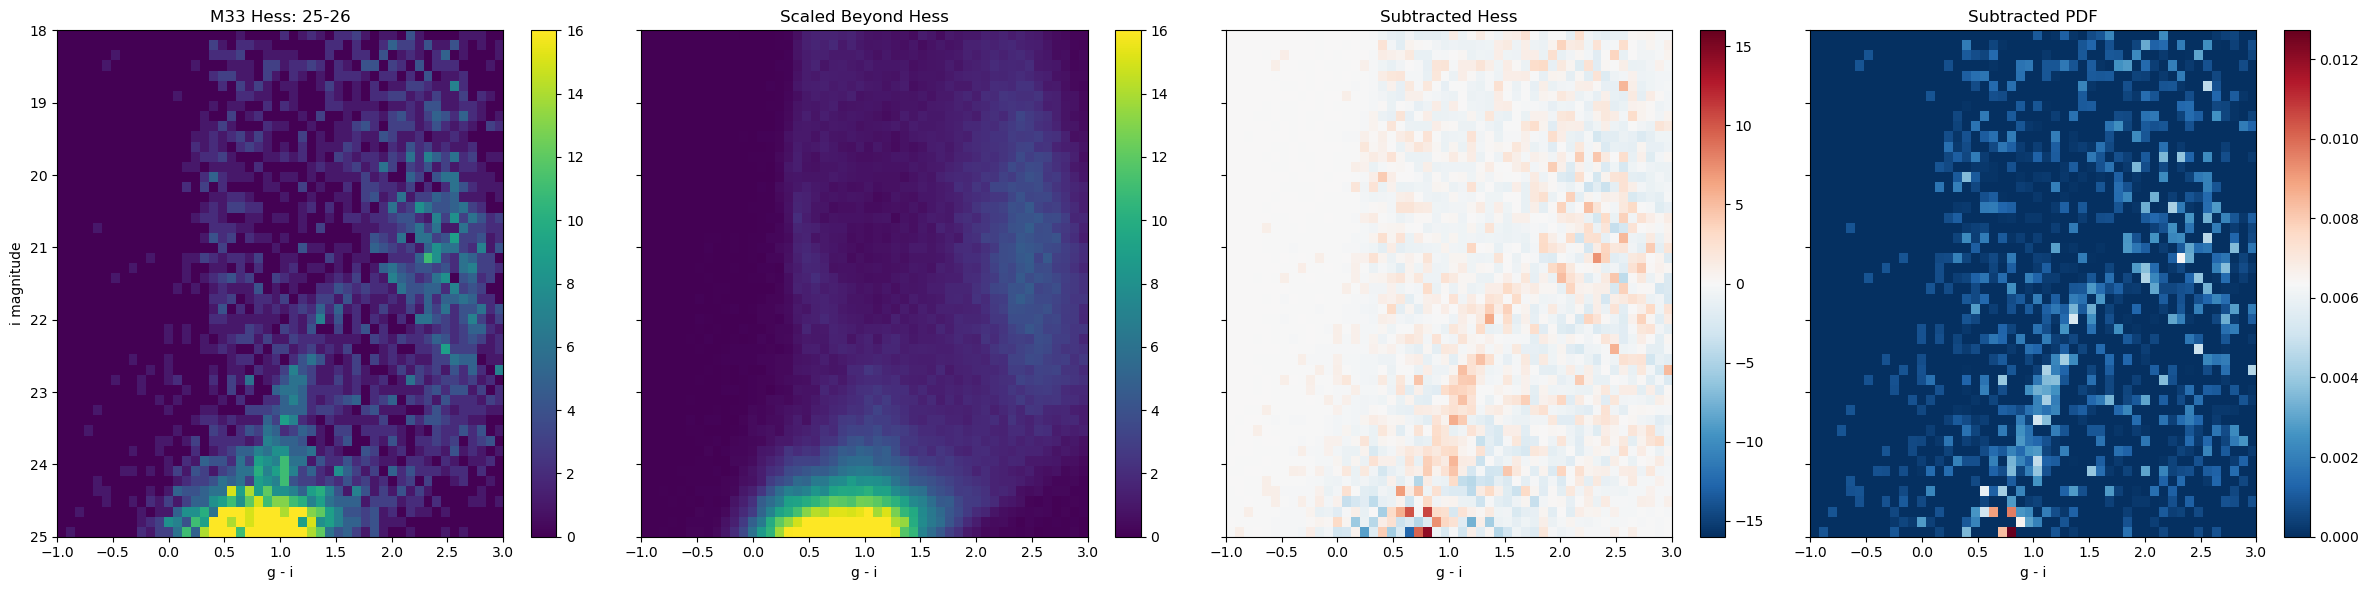

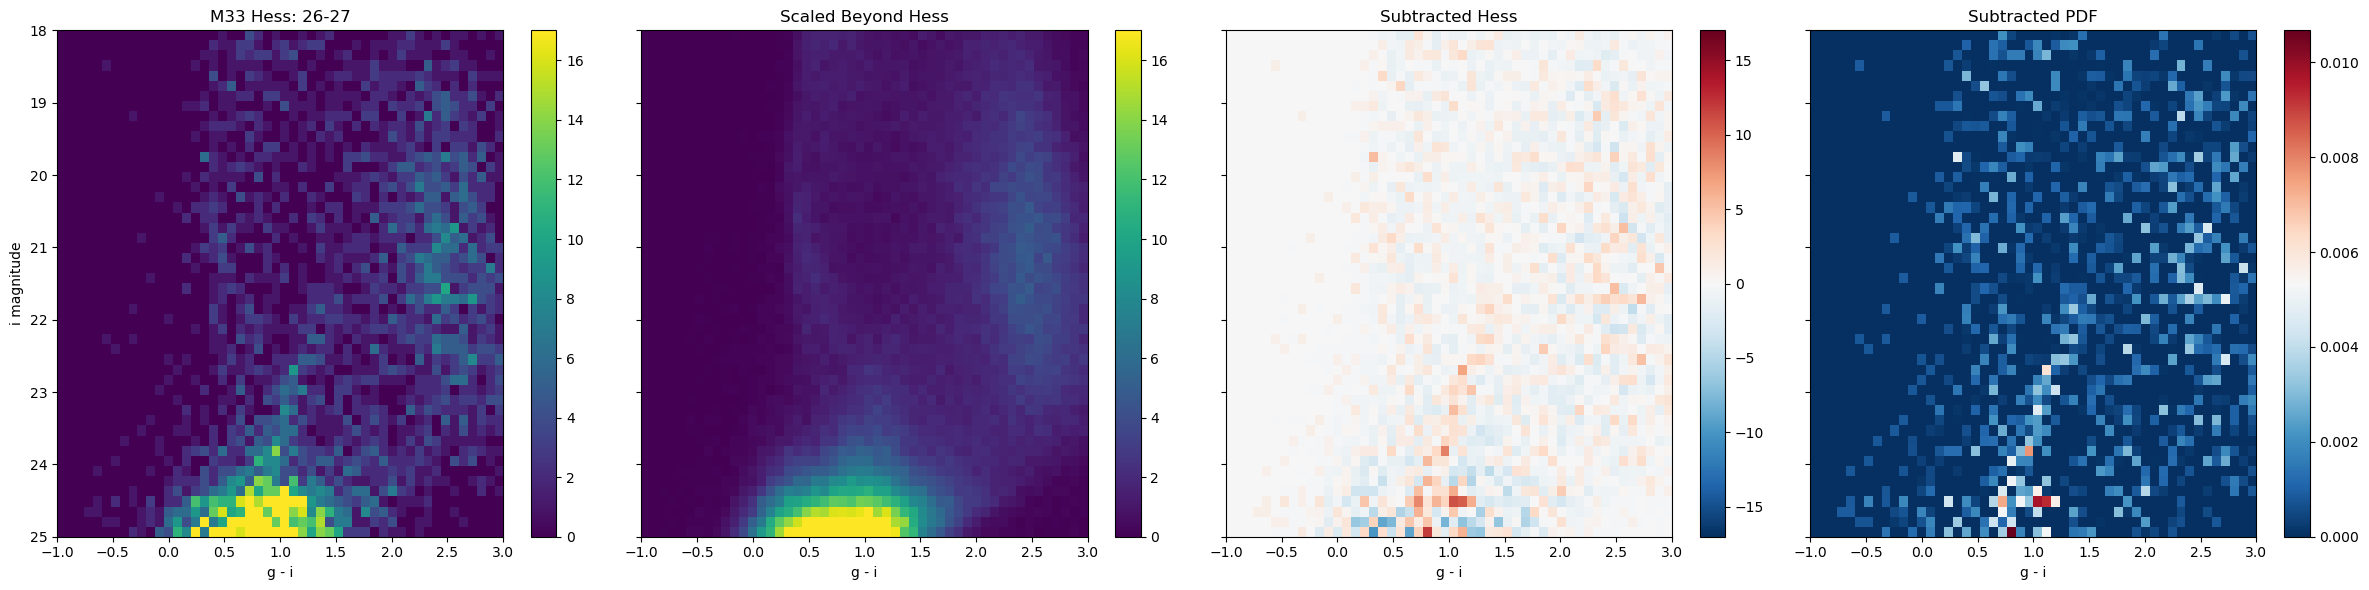

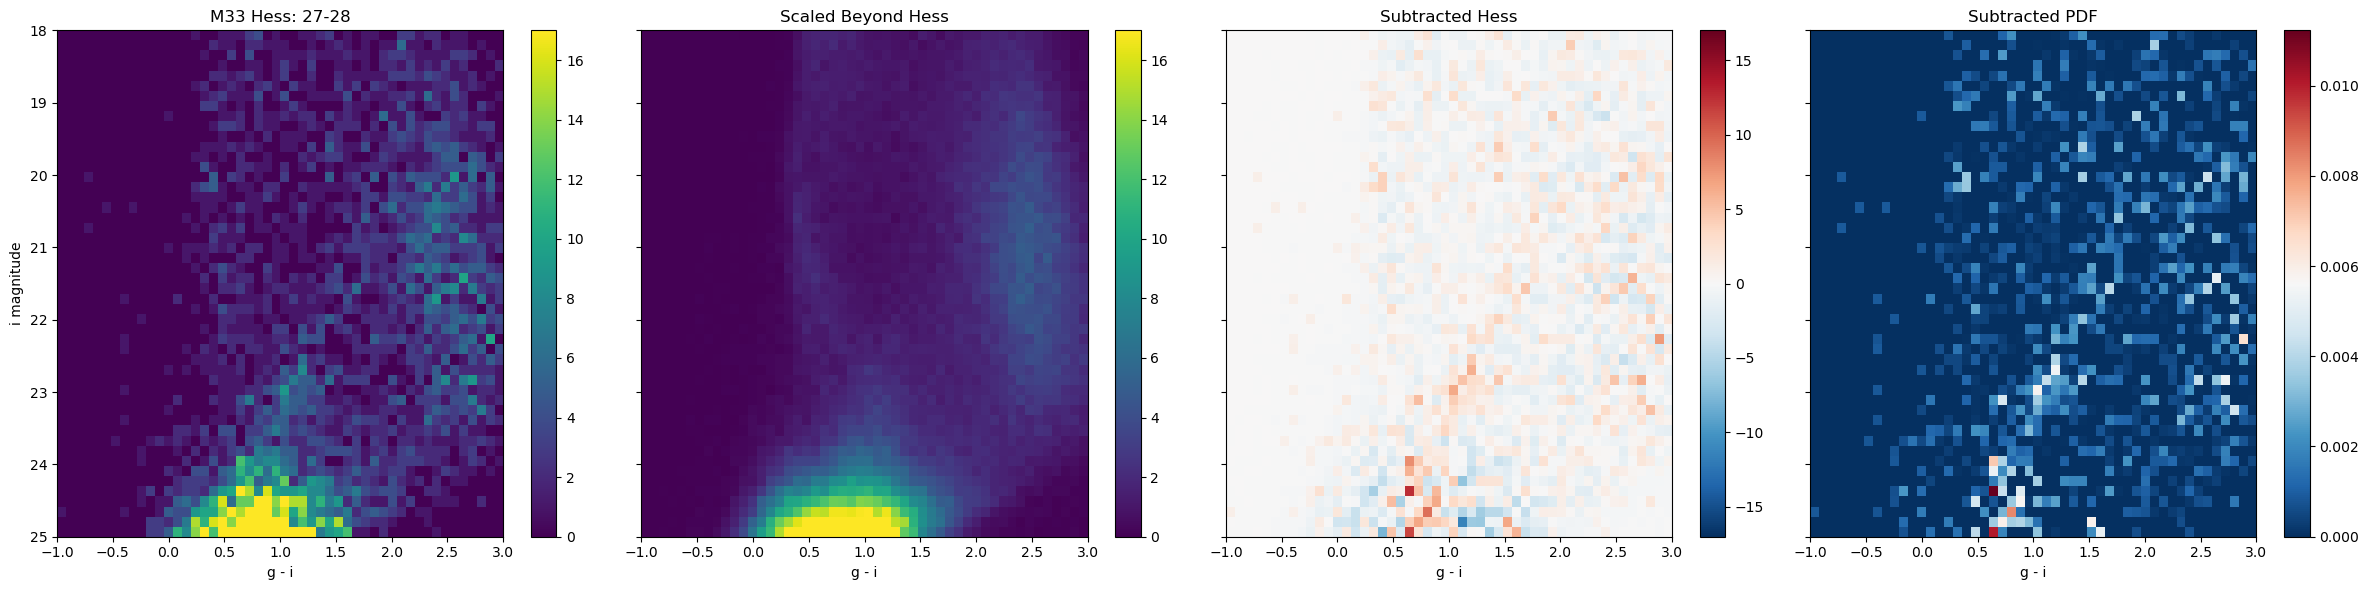

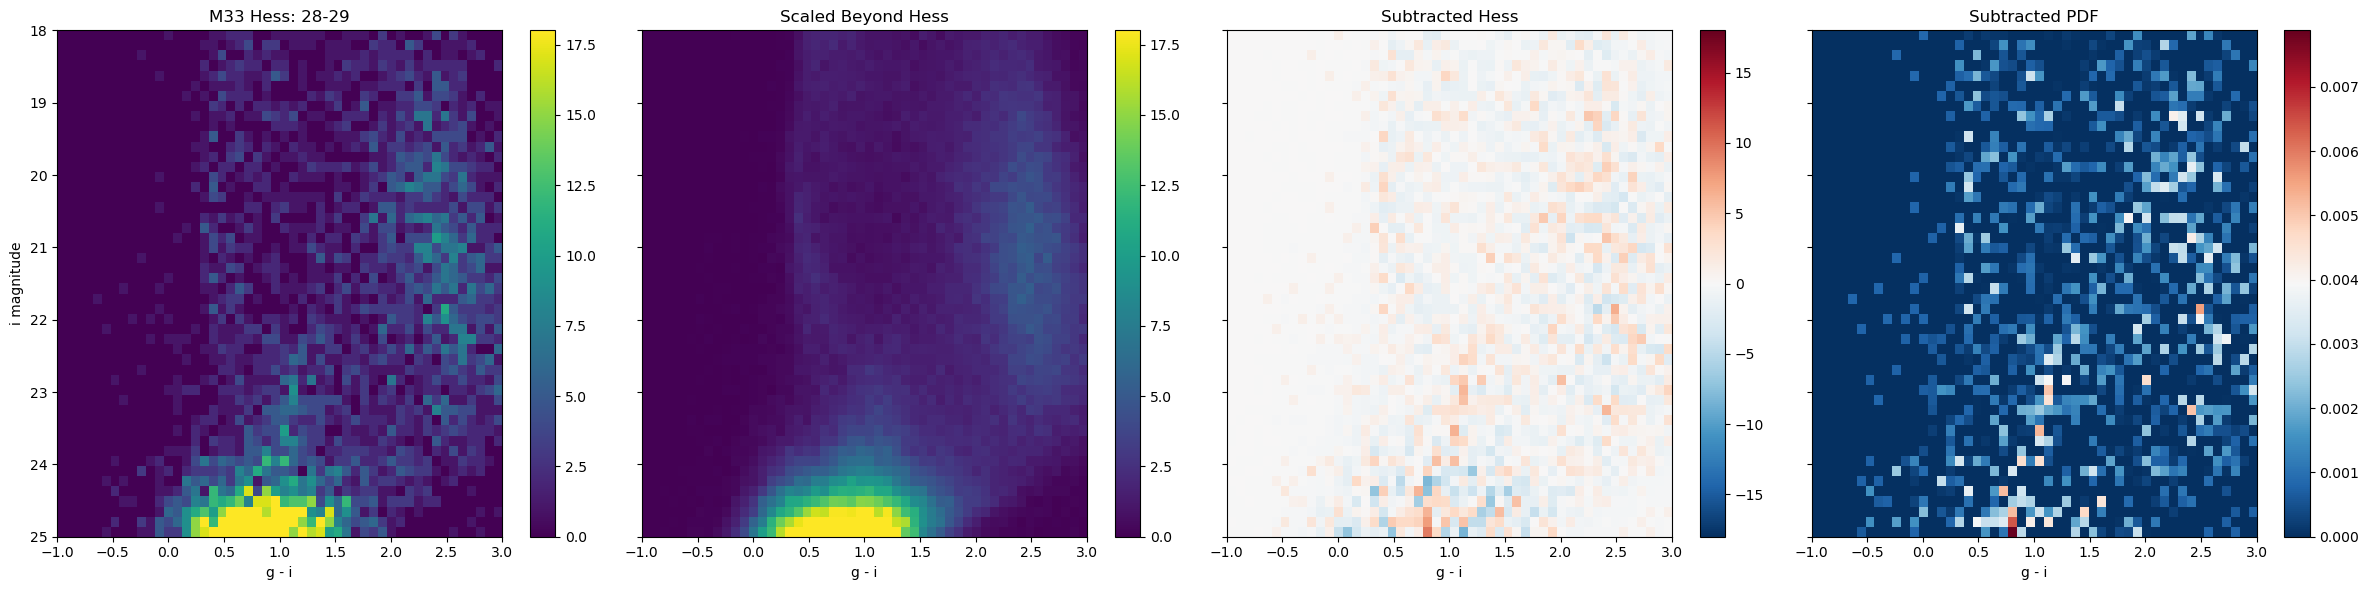

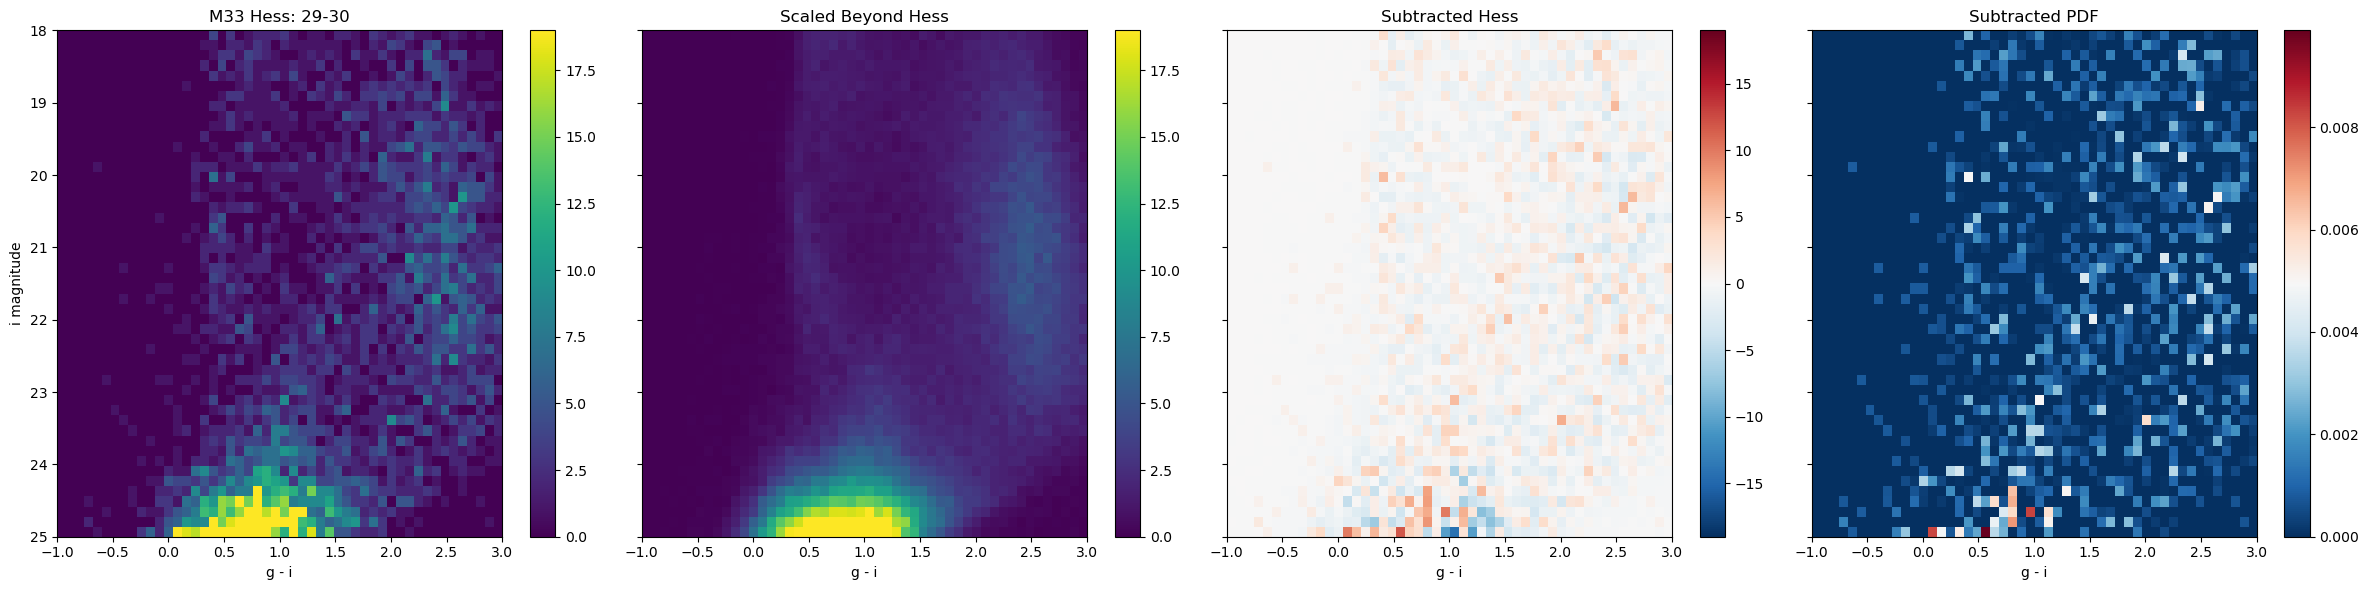

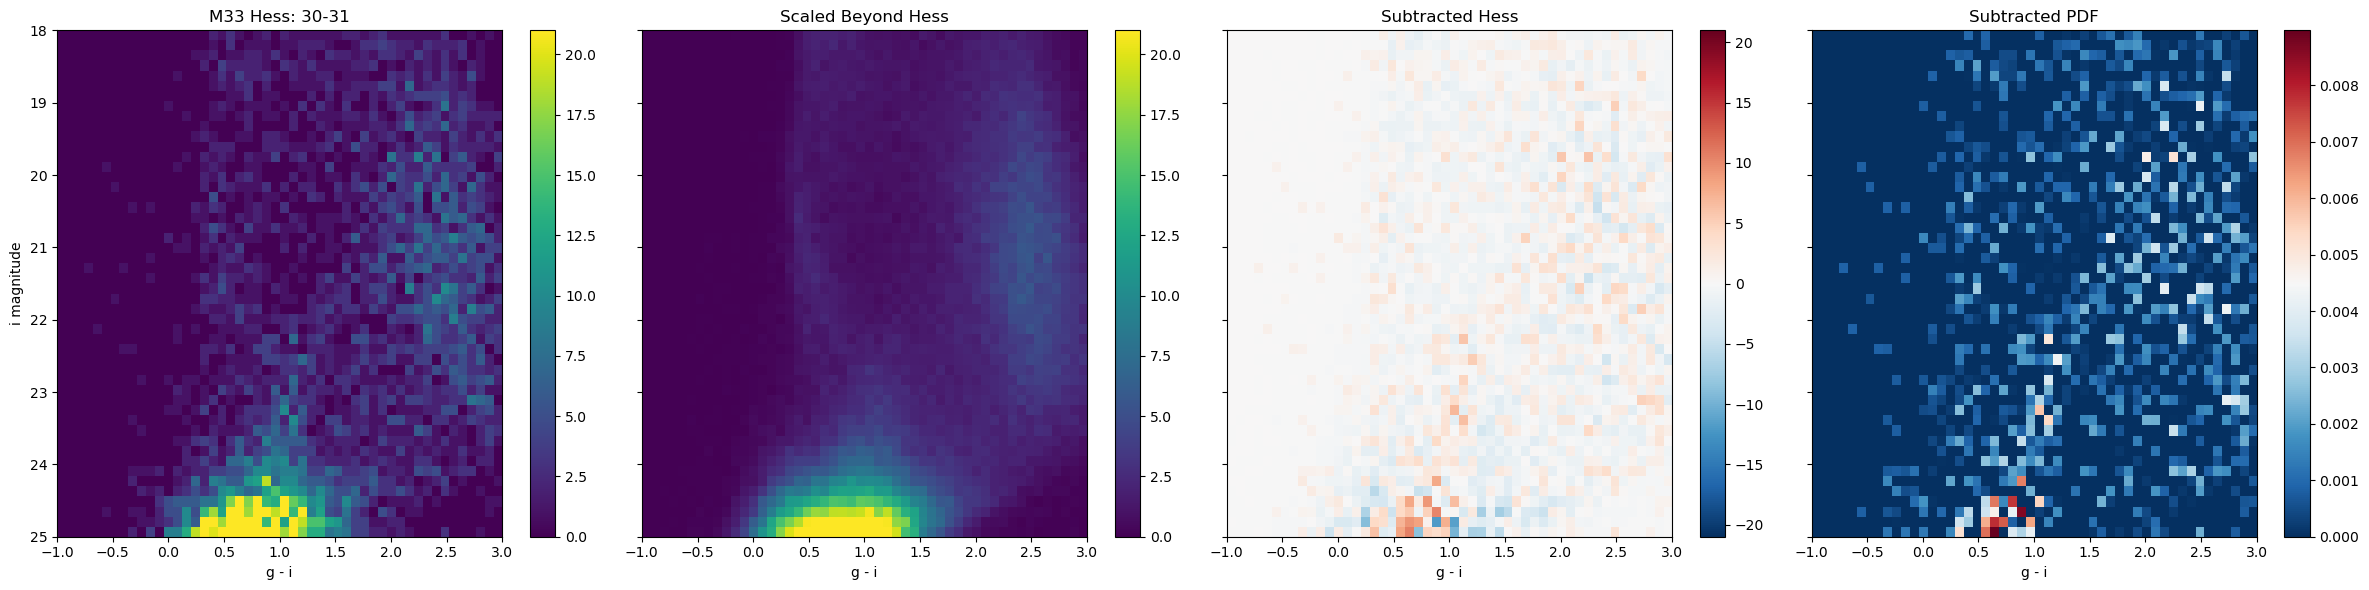

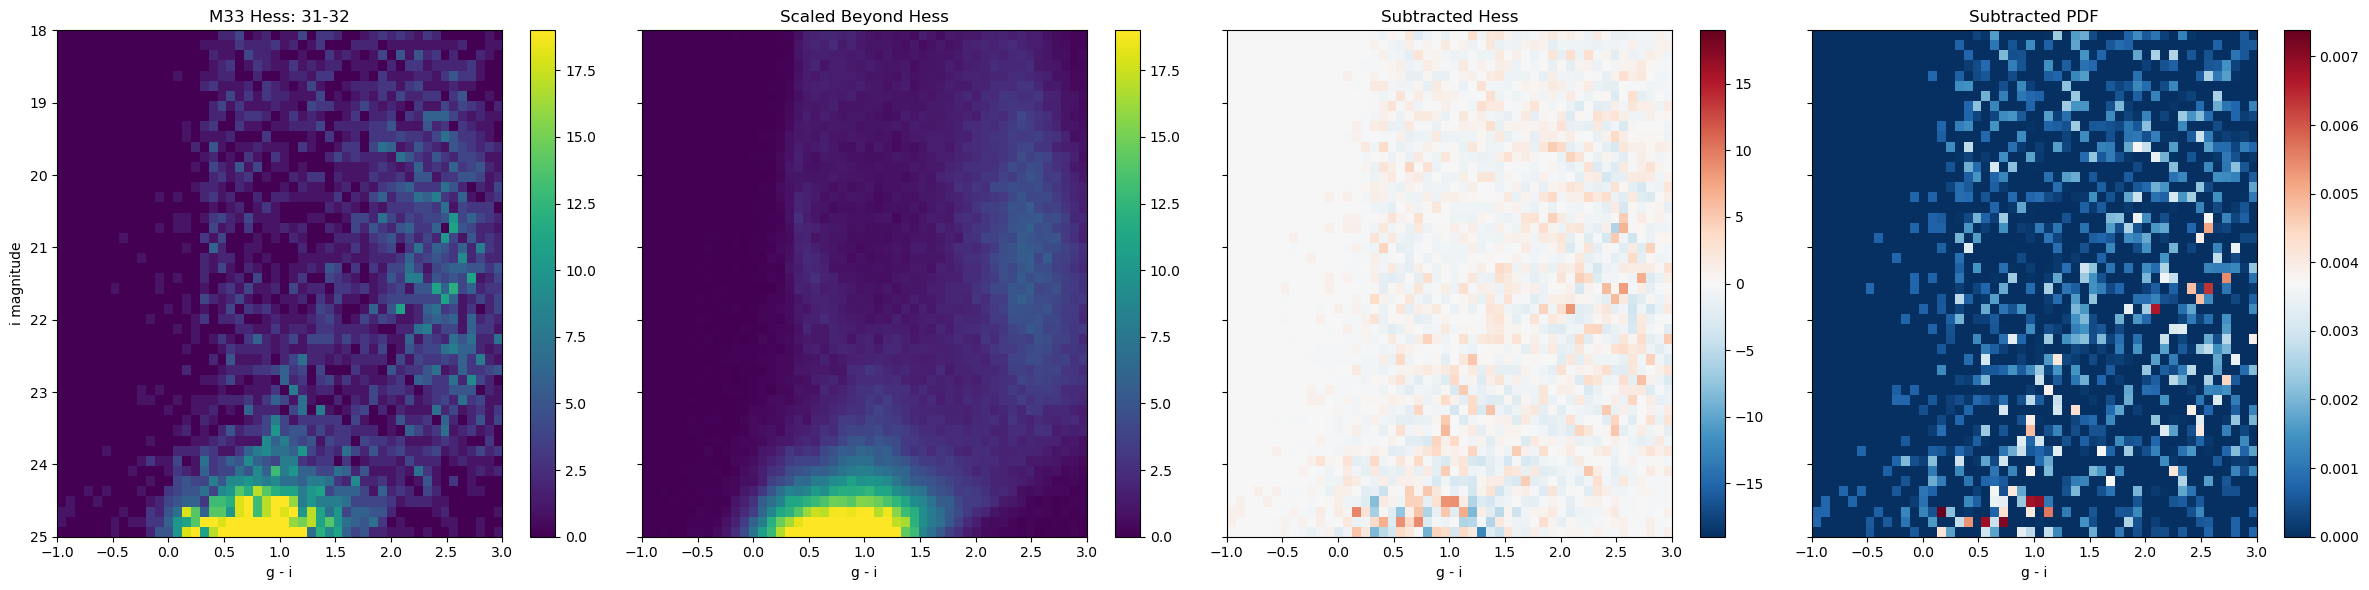

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from funcs import *
from matplotlib.patches import Ellipse

# === Constants ===
DISTANCE_KPC = 859
PA_DEG = 22
INC_DEG = 52
CENTER_COORD = SkyCoord(ra=23.4621 * u.deg, dec=30.6602 * u.deg)

# === Load and preprocess FITS data ===
with fits.open("./pandas_goodstar_bright_sr.fits") as hdul:
    data = hdul[1].data
    panda = pd.DataFrame(data.astype(data.dtype.newbyteorder('=')))

panda = panda.rename(columns={'RA': 'RA_DEG', 'Dec': 'DEC_DEG'})
panda = compute_deprojected_radius(panda)

stars = SkyCoord(ra=panda['RA_DEG'].values * u.deg, dec=panda['DEC_DEG'].values * u.deg)
separation_rad = CENTER_COORD.separation(stars).radian
panda['projected_radius_kpc'] = separation_rad * DISTANCE_KPC
panda['color'] = panda['g'] - panda['i']
panda['mag'] = panda['i']

# === Area calculation functions ===
def elliptical_annulus_area_analytic(r_in, r_out, inc_deg):
    inc_rad = np.deg2rad(inc_deg)
    return np.pi * (r_out**2 - r_in**2) * np.cos(inc_rad)

def estimate_annular_areas(n_points, max_radius_kpc, distance_kpc, pa_deg, inc_deg, area_rings, plot_radii_kpc):
    def kpc_to_arcmin(kpc): return np.rad2deg(kpc / distance_kpc) * 60

    max_arcmin = np.rad2deg(max_radius_kpc / distance_kpc) * 60
    xi = np.random.uniform(-max_arcmin, max_arcmin, n_points)
    eta = np.random.uniform(-max_arcmin, max_arcmin, n_points)

    PA_rad, inc_rad = np.deg2rad(pa_deg), np.deg2rad(inc_deg)
    xi_rot = xi * np.cos(PA_rad) + eta * np.sin(PA_rad)
    eta_rot = -xi * np.sin(PA_rad) + eta * np.cos(PA_rad)
    eta_deproj = eta_rot / np.cos(inc_rad)
    r_arcmin = np.sqrt(xi_rot**2 + eta_deproj**2)

    areas = {}
    for r_in, r_out in area_rings:
        rin_arcmin = kpc_to_arcmin(r_in)
        rout_arcmin = kpc_to_arcmin(r_out)
        mask = (r_arcmin >= rin_arcmin) & (r_arcmin < rout_arcmin)
        n_inside = np.sum(mask)
        arcmin2_to_sr = (np.pi / (180 * 60))**2
        box_area_sr = (2 * max_arcmin)**2 * arcmin2_to_sr
        box_area_kpc2 = box_area_sr * (distance_kpc ** 2)
        areas[f"{r_in}-{r_out}"] = (n_inside / n_points) * box_area_kpc2

    # Plot annuli
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(xi, eta, s=0.2, alpha=0.3, label='Random Points')
    for r_kpc in plot_radii_kpc:
        a = kpc_to_arcmin(r_kpc)
        b = a * np.cos(inc_rad)
        color = 'blue' if r_kpc < 40 else 'red'
        linestyle = '--' if r_kpc % 2 == 0 else '-'
        ellipse = Ellipse((0, 0), width=2*a, height=2*b, angle=pa_deg,
                          edgecolor=color, linestyle=linestyle, fill=False, label=f"{r_kpc} kpc")
        ax.add_patch(ellipse)
    ax.set(title="Deprojected Elliptical Annuli", xlabel="ξ (arcmin)", ylabel="η (arcmin)", aspect='equal')
    ax.grid(True); ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

    return areas

# === Hess diagram function ===
def make_hess(df, bins=(50, 50), color_range=[-1, 3], mag_range=[18, 25]):
    return np.histogram2d(df['color'], df['mag'], bins=bins, range=[color_range, mag_range])[0]

# === Radial bins ===
radial_bins_kpc = [(3, 10), (10, 13), (13, 15), (15, 16)] + [(r, r + 1) for r in range(16, 32)]
beyond_bin = (40, 77)
all_bins = radial_bins_kpc + [beyond_bin]

# === Estimate areas ===
area_results = estimate_annular_areas(
    n_points=100_000,
    max_radius_kpc=80,
    distance_kpc=DISTANCE_KPC,
    pa_deg=PA_DEG,
    inc_deg=INC_DEG,
    area_rings=all_bins,
    plot_radii_kpc=[r for pair in all_bins for r in pair]
)

# === Print area comparison table ===
print("\n=== Area Comparison for All Bins ===")
print(f"{'Bin (kpc)':<12} {'Analytic Area':>20} {'Monte Carlo Area':>25} {'% Diff':>10}")
print("-" * 75)
for (r_in, r_out) in all_bins:
    key = f"{r_in}-{r_out}"
    area_mc = area_results[key]
    area_an = elliptical_annulus_area_analytic(r_in, r_out, INC_DEG)
    pct_diff = 100 * (area_mc - area_an) / area_an
    print(f"{key:<12} {area_an:>20.2f} {area_mc:>25.2f} {pct_diff:>10.2f}")

# === Subtract and plot Hess diagrams ===
# === Subtract and plot Hess diagrams using best-fit scaling ===
hess_beyond = make_hess(panda[(panda['r_deproj_kpc'].between(*beyond_bin))])

for r_in, r_out in radial_bins_kpc:
    label = f"{r_in}-{r_out}"
    bin_df = panda[(panda['r_deproj_kpc'] >= r_in) & (panda['r_deproj_kpc'] < r_out)]
    hess_m33 = make_hess(bin_df)

    # === Best-fit background scaling (least-squares) ===
    numerator = np.sum(hess_m33 * hess_beyond)
    denominator = np.sum(hess_beyond ** 2)
    scale = numerator / denominator if denominator > 0 else 0

    hess_scaled_beyond = scale * hess_beyond
    hess_subtracted = hess_m33 - hess_scaled_beyond

    # === Normalize subtracted Hess to create a PDF ===
    hess_subtracted_pdf = hess_subtracted.copy()
    total_positive = hess_subtracted_pdf[hess_subtracted_pdf > 0].sum()
    if total_positive > 0:
        hess_subtracted_pdf[hess_subtracted_pdf < 0] = 0
        hess_subtracted_pdf /= total_positive

    vlim = np.percentile(np.abs(hess_m33), 99)

    fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)
    titles = [f"M33 Hess: {label}", "Scaled Beyond Hess", "Subtracted Hess", "Subtracted PDF"]
    hess_list = [hess_m33, hess_scaled_beyond, hess_subtracted, hess_subtracted_pdf]
    cmaps = ['viridis', 'viridis', 'RdBu_r', 'RdBu_r']
    vmins = [0, 0, -vlim, 0]; vmaxs = [vlim, vlim, vlim, hess_subtracted_pdf.max()]

    for ax, hess, title, cmap, vmin, vmax in zip(axes, hess_list, titles, cmaps, vmins, vmaxs):
        im = ax.imshow(hess.T, origin='upper', aspect='auto', extent=[-1, 3, 25, 18],
                       cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('g - i')
        if ax == axes[0]:
            ax.set_ylabel('i magnitude')
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

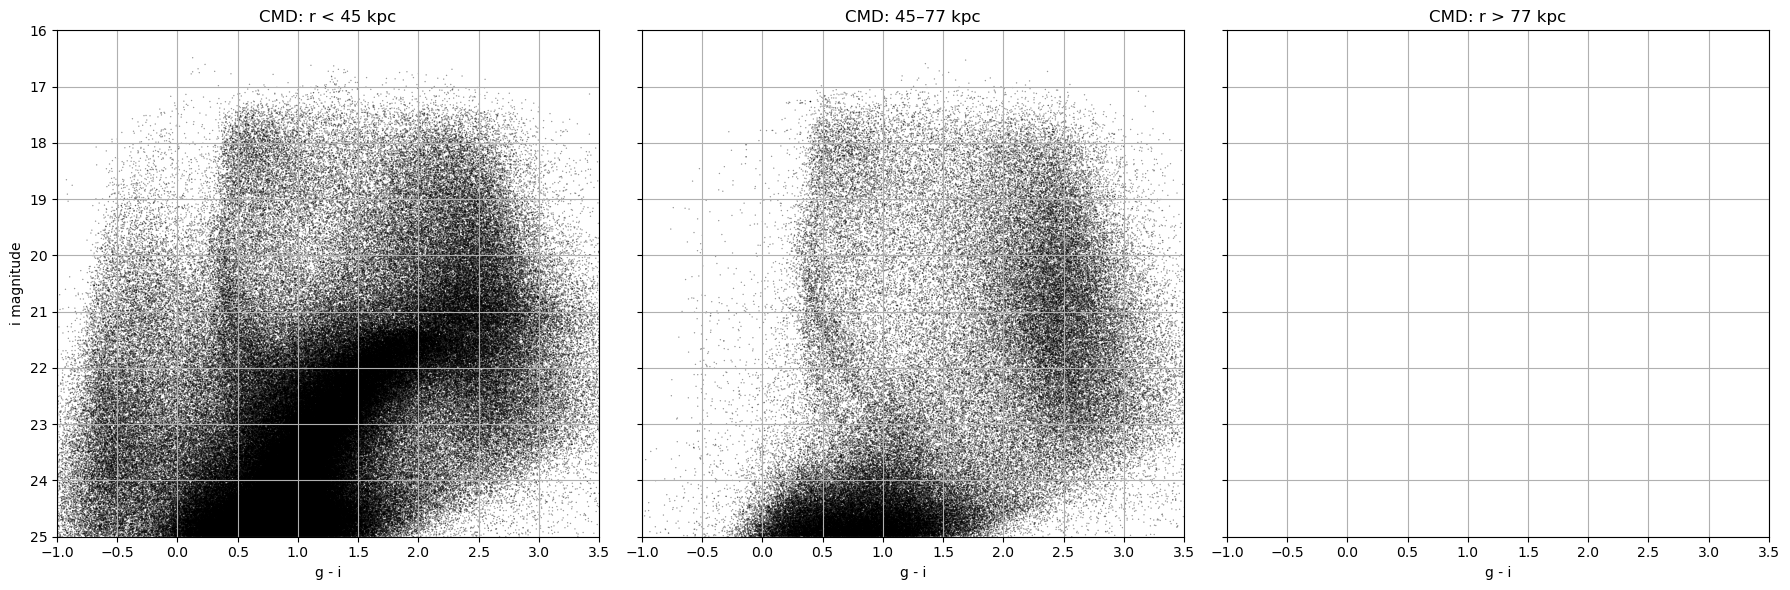

In [58]:
# === Radius bounds ===
r_min = 45
r_max = 77

# === Filter subsets ===
subset_inner = panda[panda['r_deproj_kpc'] < r_min]
subset_middle = panda[(panda['r_deproj_kpc'] >= r_min) & (panda['r_deproj_kpc'] < r_max)]
subset_outer = panda[panda['r_deproj_kpc'] > r_max]

# === Plot all CMDs in one row ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, subset, title in zip(
    axes,
    [subset_inner, subset_middle, subset_outer],
    [f"CMD: r < {r_min} kpc", f"CMD: {r_min}–{r_max} kpc", f"CMD: r > {r_max} kpc"]
):
    ax.scatter(subset['color'], subset['mag'], s=1, alpha=0.4, color='black', edgecolors='none')
    ax.set_xlim(-1, 3.5)
    ax.set_ylim(25, 16)
    ax.set_title(title)
    ax.set_xlabel("g - i")
    ax.grid(True)

axes[0].set_ylabel("i magnitude")
plt.tight_layout()
plt.show()